In [1]:
from dataclasses import replace

import jax
import jax.numpy as jnp
import matplotlib as mplib
import matplotlib.pyplot as plt
import numpy as np
import optax
import shapely.geometry as shap_geom
from flax import nnx
from shapely.prepared import prep

import moto.src.bc as _bc
import moto.src.cons_loss as _cons_loss
import moto.src.geometry as _geom
import moto.src.material as _mat
import moto.src.material_points as _mp
import moto.src.mesher as _mesher
import moto.src.network as _net
import moto.src.nl_solver as _nlsolv
import moto.src.solve as _solve
import moto.src.utils as _utils
import moto.src.viz as _viz
from moto.src.hyperelastic_mpm import HyperelasticMPM, StructField

_Ext = _utils.Extent

jax.config.update("jax_enable_x64", True)
GIF_DIR = "frames"
GIF_PATH = "mpm.gif"
GIF_FPS = 3
frames = []

_Field = StructField

/mount/moritadbjp/sharefilesjp/work/MOTO/MOTO/moto/src/nl_solver.py:22: UserWarning: petsc4py library not found. PETSc solver is not available.
  warnings.warn("petsc4py library not found. PETSc solver is not available.")
/mount/moritadbjp/sharefilesjp/work/MOTO/MOTO/moto/src/nl_solver.py:27: UserWarning: pypardiso library not found. Some solvers may not be available.
  warnings.warn("pypardiso library not found. Some solvers may not be available.")


## Geometry & Mesh

In [3]:
bbox = _geom.BrepGeometry("../brep/rect_domain_expt_1.json")
bar_bbox = _geom.BrepGeometry("../brep/cantilever_expt_1.json")
mesh = _mesher.grid_mesh_brep(
  brep=bbox,
  nelx_desired=80,
  nely_desired=40,
  dofs_per_node=2,
  gauss_order=2,
)

## Material Points Generation 


In [4]:
prepared_beam_geom = prep(bar_bbox.geometry)
inside = np.array(
  [prepared_beam_geom.covers(shap_geom.Point(xy)) for xy in mesh.elem_centers],
  dtype=bool,
)

# Element IDs to populate
occupied_element_ids = np.where(inside)[0]

# MPs
num_mp_per_elem_per_dim = 4
mp_coords = _mesher.generate_mp_coords_in_occupied_elements(
  mesh,
  occupied_element_ids,
  num_mp_per_elem_per_dim,
)
num_mat_pts = mp_coords.shape[0]

# Boundary conditions

In [5]:
face_tol = float(np.asarray(mesh.elem_size)[0]) * 0.5

left_faces = _bc.identify_faces(mesh, edges=[bar_bbox.edges[3]], tol=face_tol)
nL = len(left_faces)

left_clamped = _bc.DirichletBC(
  elem_faces=left_faces,
  values=[(_Field.U, np.zeros(nL)), (_Field.V, np.zeros(nL))],
  name="clamped-left",
)
bcs_list = [left_clamped]
bc = _bc.process_boundary_conditions(bcs_list, mesh)


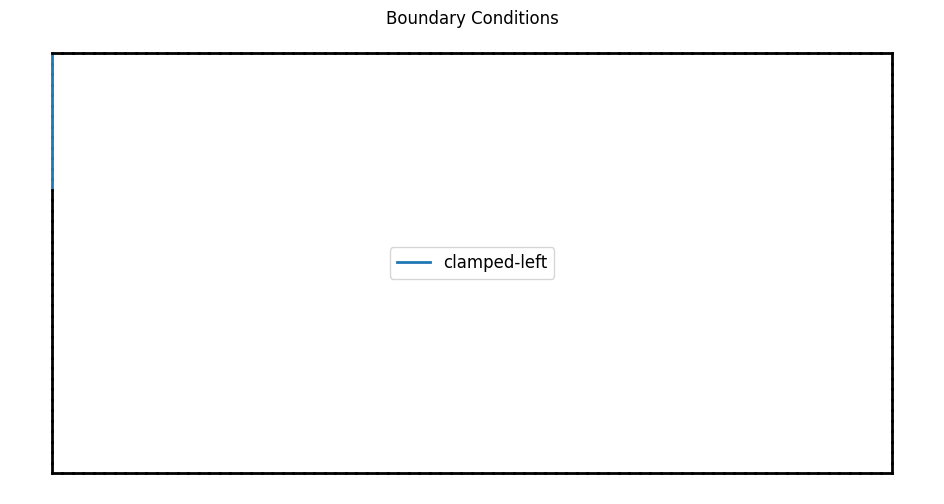

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
_viz.plot_grid_mesh(mesh, ax=ax, colorbar=False)
_viz.plot_bc(bcs_list, mesh, ax=ax)
plt.show()

## Material Initialization

In [7]:
youngs_modulii = jnp.array([12.0, 3.0, 1.0, 1e-4]) * 1e9
mass_densities = jnp.array([4.0, 1.6, 0.75, 1e-4]) * 1e3

poissons_ratios = jnp.array([0.4, 0.4, 0.4, 0.4])
yield_strengths = jnp.array([2.0, 1.2, 0.8, 1e-4]) * 1e5
lame_lam, lame_mu = _mat.get_lame_parameters_from_youngs_modulus_and_poissons_ratio(
  youngs_modulii, poissons_ratios
)

num_materials = len(youngs_modulii)
cmap = mplib.colors.ListedColormap(_viz.mat_colors[:num_materials])

In [8]:
# MP half-lengths and volumes
thickness = 1.0e-3
elem_size = jnp.asarray(mesh.elem_size)
half_length_per_mp = elem_size / (2 * num_mp_per_elem_per_dim)
volume_per_mp = (
  thickness * jnp.prod(elem_size) / (num_mp_per_elem_per_dim**mesh.num_dim)
)

max_nodes = 3**mesh.num_dim
max_elems = 2**mesh.num_dim

mp_state, _ = _mp.initialize_new_material_points(
  num_pts=num_mat_pts,
  num_dim=mesh.num_dim,
  max_nodes_per_point=max_nodes,
  max_elems_per_point=max_elems,
)
mass_per_mp = volume_per_mp * jnp.mean(mass_densities)  # Assign avg density initially

mp_state = replace(
  mp_state,
  coord=mp_coords,
  volume=volume_per_mp * jnp.ones((num_mat_pts,), dtype=jnp.float64),
  volume0=volume_per_mp * jnp.ones((num_mat_pts,), dtype=jnp.float64),
  mass=mass_per_mp * jnp.ones((num_mat_pts,), dtype=jnp.float64),
  domain_length=jnp.tile(half_length_per_mp[None, :], (num_mat_pts, 1)),
  domain_length0=jnp.tile(half_length_per_mp[None, :], (num_mat_pts, 1)),
)

## Density filter

In [9]:
density_filter = _utils.create_density_filter(
  coords=mp_coords,
  cutoff_distance=1.5 * mesh.elem_size[0],
  filter_type=_utils.Filters.CIRCULAR,
)

#  Forces on material points

In [10]:
# pick loaded material points by bbox
bar_mid = (bar_bbox.geometry.bounds[1] + bar_bbox.geometry.bounds[3]) / 2
bar_right = bar_bbox.geometry.bounds[2]
force_bbox = _mesher.BoundingBox(
  x=_Ext(min=bar_right - 1.2 * face_tol, max=bar_right + face_tol),
  y=_Ext(min=bar_mid - 1.2 * face_tol, max=bar_mid + face_tol),
)

mask = _mesher.compute_point_indices_in_box(np.asarray(mp_state.coord), force_bbox)
loaded_ids = np.where(np.asarray(mask))[0]
if loaded_ids.size == 0:
  raise ValueError(
    "No material points found in force_bbox; widen bbox or check coords."
  )

# distribute a total load across those MPs
F_total = -2.5000e2  # total downward force (N)
f_per_mp = F_total / loaded_ids.size

mp_point_force = jnp.zeros((num_mat_pts, mesh.num_dim), dtype=jnp.float64)
mp_point_force = mp_point_force.at[loaded_ids, 1].set(f_per_mp)  # y-dir = 1

mp_state = replace(mp_state, point_force=mp_point_force)
print(f"Applied total force {F_total:.3e} N over {loaded_ids.size} material points.")


Applied total force -2.500e+02 N over 4 material points.


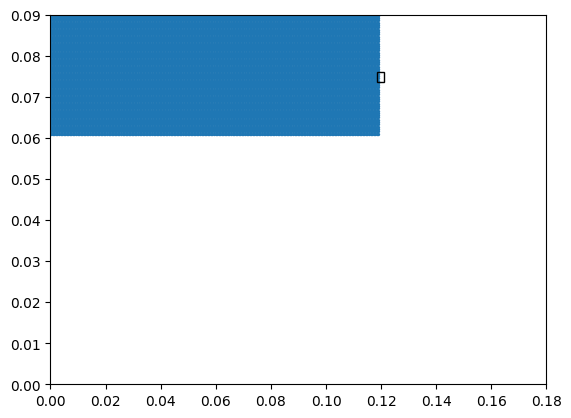

In [11]:
fig, ax = plt.subplots()
img = ax.scatter(
  mp_state.coord[:, 0],
  mp_state.coord[:, 1],
  s=2,
)

for bbox in [force_bbox]:
  rect = plt.Rectangle(
    (float(bbox.x.min), float(bbox.y.min)),
    float(bbox.x.max - bbox.x.min),
    float(bbox.y.max - bbox.y.min),
    linewidth=1.0,
    edgecolor="black",
    facecolor="None",
  )
  ax.add_patch(rect)

ax.set_xlim([float(mesh.bounding_box.x.min), float(mesh.bounding_box.x.max)])
ax.set_ylim([float(mesh.bounding_box.y.min), float(mesh.bounding_box.y.max)])

plt.show()
plt.pause(0.0001)

## Network and projections

In [12]:
symm_map = _net.Symmetry()
fourier_proj = _net.FourierProjection(
  num_input_dim=2,
  num_terms=100,
  min_radius=0.009,  # 0.0081,
  max_radius=0.5,
)

topnet = _net.TopNet(
  num_neurons=[2 * fourier_proj.num_terms, 40, 40, num_materials],
  rngs=nnx.Rngs(1234),  # 1234 #9
  use_batch_norm=True,
)

In [13]:
pts_xy = symm_map.apply(mp_state.coord)
pts_xy_fourier = fourier_proj.apply(pts_xy)

In [14]:
loss_params = [_cons_loss.LogBarrierParams(t0=3.0, mu=1.02)]

## Solver Setup

In [15]:
nr_tol, max_nr_iter = 1e-7, 50

solver_settings = {
  "linear": {"solver": _nlsolv.LinearSolvers.SCIPY_SPARSE, "rtol": 1e-12},
  "nonlinear": {
    "max_iter": max_nr_iter,
    "threshold": nr_tol,
    "lam_min": 0.01,
    "line_search_max_iter": 12,
    "line_search_shrink": 0.5,
    "line_search_alpha_min": 1e-6,
    "line_search_armijo_c": 1e-4,
  },
}

mpm_problem = HyperelasticMPM(
  solver_settings=solver_settings,
  mesh=mesh,
)

du_guess = jnp.zeros((mesh.num_dofs,)) + 1e-3
du_guess = du_guess.at[bc["fixed_dofs"]].set(0.0)
gravity_vec = jnp.zeros((mesh.num_dim,))

In [16]:
eta = 0.5
rho_min = 1e-3

In [17]:
@nnx.jit(static_argnames=("num_load_steps",))
def loss_function(
  net: _net.TopNet,
  mp_state0: _mp.MaterialPointConfig,
  penal: float,
  num_load_steps: int,
  gravity_vec: jnp.ndarray,
  max_mass: float,
  obj_0: float,
  epoch: int,
) -> jnp.ndarray:
  # compute pseudo-densities
  pseudo_densities = jax.nn.softmax(net(pts_xy_fourier), axis=-1)
  penal_matfrac = rho_min + (1.0 - rho_min) * (pseudo_densities**penal)

  lam = jnp.einsum("m, pm -> p", lame_lam, penal_matfrac)
  mu = jnp.einsum("m, pm -> p", lame_mu, penal_matfrac)

  matpt_massdens = jnp.einsum("m, pm -> p", mass_densities, pseudo_densities)
  matpt_mass = matpt_massdens * mp_state0.volume0

  mp_state_in = replace(mp_state0, pseudo_density=pseudo_densities, mass=matpt_mass)

  # solve MPM and compute objective
  mp_final, _ = _solve.newton_solve(
    mesh=mesh,
    mp_state=mp_state_in,
    bc=bc,
    du_guess=du_guess,
    load_steps=num_load_steps,
    gravity=gravity_vec,
    mpm_problem=mpm_problem,
    lame_lambda=lam,
    lame_mu=mu,
    mp_point_force=mp_state_in.point_force,
  )
  obj = jnp.einsum("pd, pd -> ", mp_state_in.point_force, mp_final.displacement)

  # volume constraint
  net_mass = jnp.sum(matpt_mass)
  mass_cons = (net_mass / max_mass) - 1.0  # <= 0

  # loss
  loss = _cons_loss.combined_loss(
    obj / obj_0,
    jnp.array([mass_cons]),
    [_cons_loss.ConstraintTypes.INEQUALITY],
    loss_params,
    epoch,
  )

  return loss, (mp_final, pseudo_densities, obj, net_mass)

## Optimization

In [18]:
def optimize_design(
  net: _net.TopNet,
  mp_state0: _mp.MaterialPointConfig,
  max_mass: float,
  max_epoch: int,
  num_load_steps: int = 15,
  gravity_vec=None,
  lr: float = 1e-2,
  plot_interval: int = 2,
):
  # gravity vector
  if gravity_vec is None:
    gravity_vec = jnp.zeros((mesh.num_dim,), dtype=jnp.float64)

  obj_0 = 1.0
  opt = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(lr),
  )
  optimizer = nnx.ModelAndOptimizer(topnet, opt)
  convg_history = {
    "epoch": [],
    "objective": [],
    "volfrac_cons": [],
  }

  for epoch in range(max_epoch):
    penal = min(5.0, 1.0 + epoch * 0.05)

    (loss, (mp_final, mat_fracs, obj, vol_frac)), grad_loss = nnx.value_and_grad(
      loss_function, has_aux=True
    )(net, mp_state0, penal, num_load_steps, gravity_vec, max_mass, obj_0, epoch)

    optimizer.update(grad_loss)

    status = f"epoch {epoch} Loss {loss:.2E} J {obj:.2E} vf {vol_frac:.2F}"
    print(status)
    for key, value in zip(
      [
        "epoch",
        "objective",
        "volfrac_cons",
      ],
      [
        epoch,
        obj,
        vol_frac,
      ],
    ):
      convg_history[key].append(jax.lax.stop_gradient(value))
    if epoch == 0 or epoch == 10:
      obj_0 = jax.lax.stop_gradient(obj)

    if epoch % plot_interval == 0:
      coords = np.asarray(mp_final.coord)
      mat_idx = jnp.argmax(mat_fracs, axis=-1)

      _, ax = plt.subplots()
      img = ax.scatter(coords[:, 0], coords[:, 1], s=2, c=mat_idx, cmap=cmap)
      ax.set_xlim([float(mesh.bounding_box.x.min), float(mesh.bounding_box.x.max)])
      ax.set_ylim([float(mesh.bounding_box.y.min), float(mesh.bounding_box.y.max)])
      plt.colorbar(img, ax=ax)
      plt.show()
      plt.pause(1e-6)

  return mp_final, mat_fracs, net, convg_history


In [19]:
mass_frac = 0.3912
V_domain = jnp.sum(mp_state.volume0)
rho_ref = jnp.mean(mass_densities[:-1])
max_mass = mass_frac * V_domain * rho_ref

/mount/moritadbjp/sharefilesjp/work/MOTO/MOTO/.venv/lib/python3.12/site-packages/jax/_src/ops/scatter.py:104: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(


step 1/1
NR converged in 6 iters, res_norm/res_norm_0: 2.4005491125980427e-09
step 1/1
epoch 0 Loss 9.33E+00 J 3.19E+00 vf 0.01


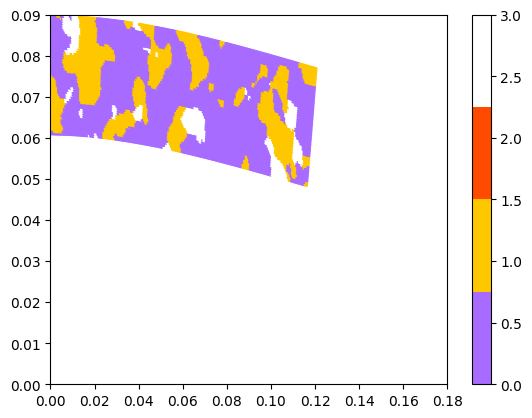

step 1/1
NR converged in 6 iters, res_norm/res_norm_0: 5.311236643985701e-12
step 1/1
epoch 1 Loss 5.97E+00 J 2.79E+00 vf 0.01
step 1/1
NR converged in 6 iters, res_norm/res_norm_0: 1.3600150398597772e-10
step 1/1
epoch 2 Loss 5.17E+00 J 3.37E+00 vf 0.01


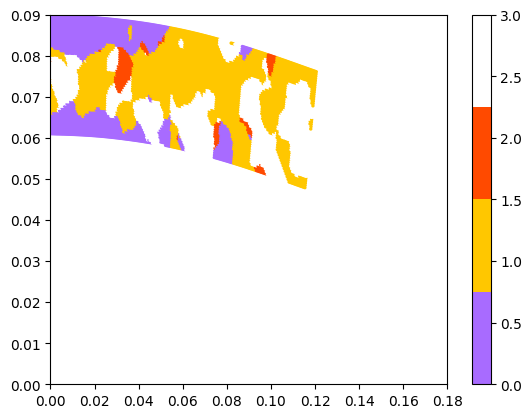

step 1/1
NR converged in 6 iters, res_norm/res_norm_0: 1.0734239116398474e-08
step 1/1
epoch 3 Loss 4.60E+00 J 4.30E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.2814794731309846e-12
step 1/1
epoch 4 Loss 4.21E+00 J 5.50E+00 vf 0.00


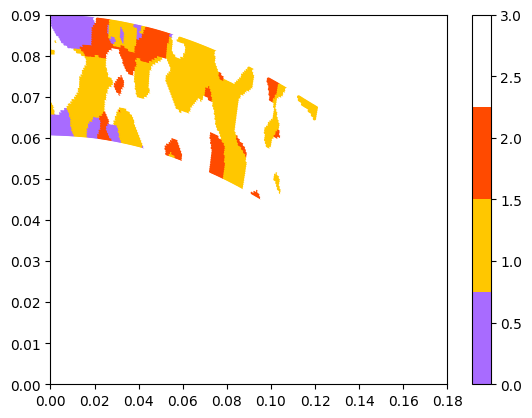

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 8.850594228885437e-11
step 1/1
epoch 5 Loss 3.98E+00 J 6.73E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.1172298799769524e-10
step 1/1
epoch 6 Loss 3.83E+00 J 7.52E+00 vf 0.00


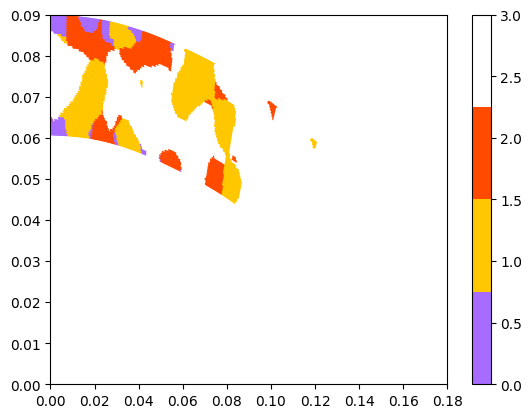

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.2527375693570108e-11
step 1/1
epoch 7 Loss 3.71E+00 J 7.86E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 8.821786020468854e-12
step 1/1
epoch 8 Loss 3.63E+00 J 8.06E+00 vf 0.00


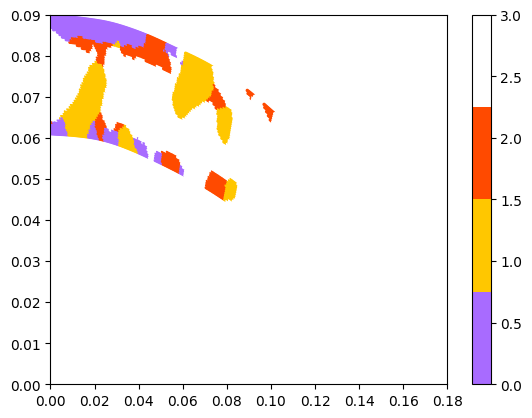

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 8.10774185305313e-12
step 1/1
epoch 9 Loss 3.55E+00 J 8.32E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.031160177743621e-11
step 1/1
epoch 10 Loss 3.48E+00 J 8.66E+00 vf 0.00


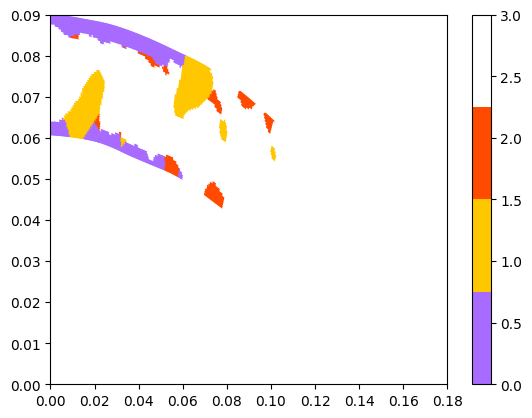

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 9.809646091661678e-11
step 1/1
epoch 11 Loss 1.64E+00 J 9.03E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.4459427080884623e-09
step 1/1
epoch 12 Loss 1.61E+00 J 1.03E+01 vf 0.00


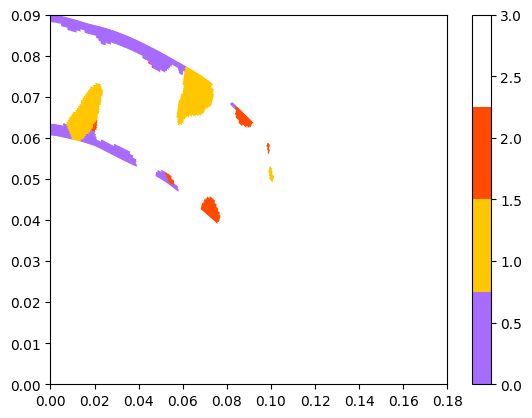

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 7.00692416463469e-08
step 1/1
epoch 13 Loss 1.63E+00 J 1.11E+01 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.684152366069349e-10
step 1/1
epoch 14 Loss 1.63E+00 J 1.12E+01 vf 0.00


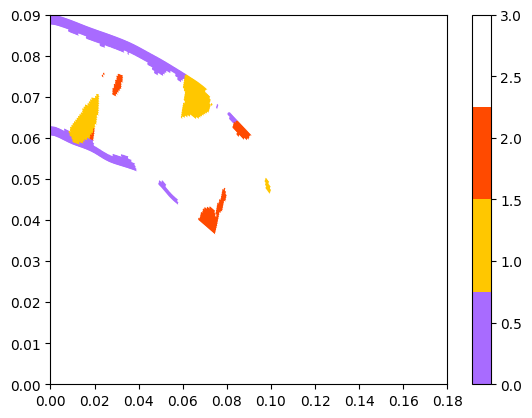

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.0783550252387586e-09
step 1/1
epoch 15 Loss 1.61E+00 J 1.07E+01 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 6.656611709070202e-08
step 1/1
epoch 16 Loss 1.59E+00 J 9.90E+00 vf 0.00


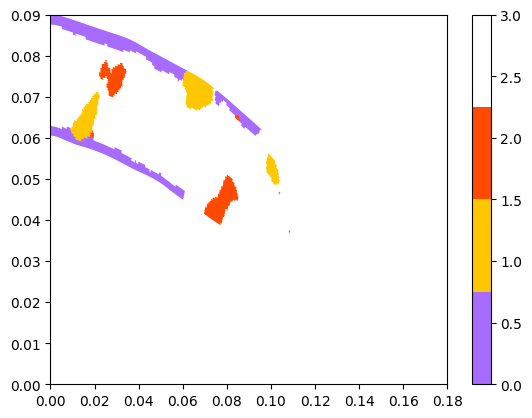

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.297833121713785e-08
step 1/1
epoch 17 Loss 1.60E+00 J 9.28E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 7.392225179394638e-09
step 1/1
epoch 18 Loss 1.57E+00 J 9.23E+00 vf 0.00


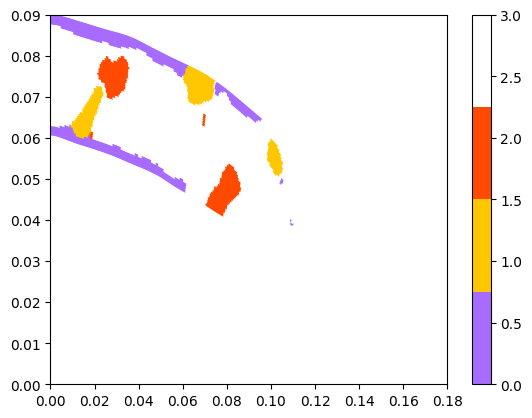

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 4.911381423450648e-09
step 1/1
epoch 19 Loss 1.54E+00 J 9.69E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.6939700325013234e-08
step 1/1
epoch 20 Loss 1.53E+00 J 9.91E+00 vf 0.00


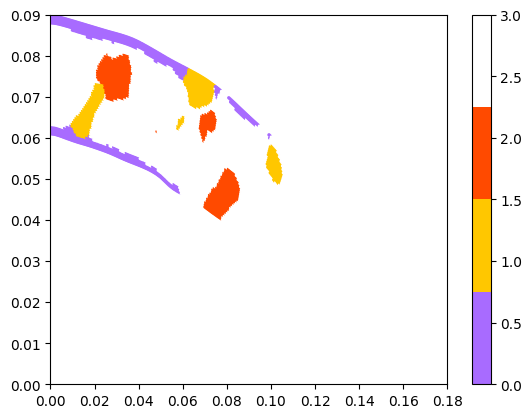

step 1/1
NR converged in 14 iters, res_norm/res_norm_0: 1.687537564174478e-08
step 1/1
epoch 21 Loss 1.53E+00 J 9.72E+00 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.9333971314257853e-13
step 1/1
epoch 22 Loss 1.52E+00 J 9.14E+00 vf 0.00


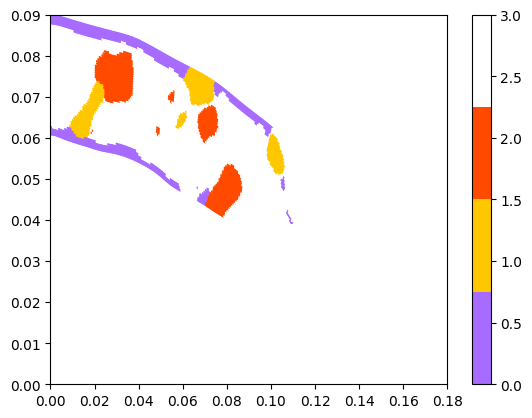

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.125565872042768e-08
step 1/1
epoch 23 Loss 1.51E+00 J 8.98E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.4633537810852789e-08
step 1/1
epoch 24 Loss 1.50E+00 J 9.22E+00 vf 0.00


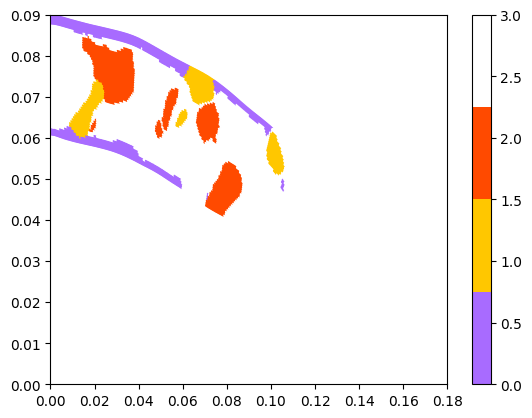

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.235471865079075e-08
step 1/1
epoch 25 Loss 1.48E+00 J 9.33E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 6.542972307972633e-09
step 1/1
epoch 26 Loss 1.46E+00 J 9.06E+00 vf 0.00


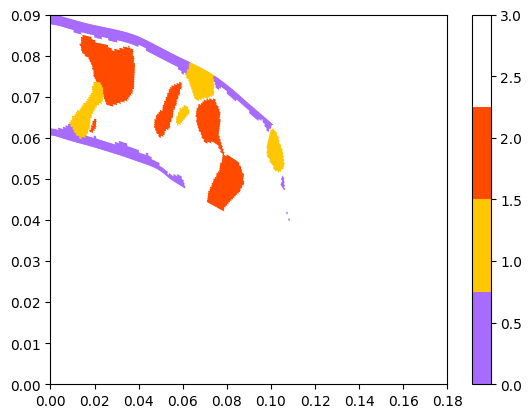

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 7.663297932970305e-09
step 1/1
epoch 27 Loss 1.44E+00 J 8.75E+00 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.2069050785017965e-09
step 1/1
epoch 28 Loss 1.42E+00 J 8.61E+00 vf 0.00


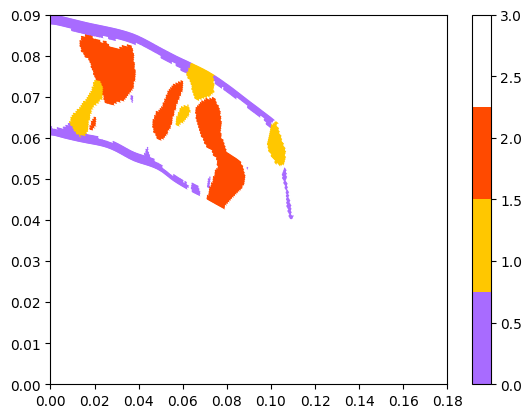

step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 5.018813254163116e-10
step 1/1
epoch 29 Loss 1.44E+00 J 8.87E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 5.9467936798680237e-08
step 1/1
epoch 30 Loss 1.40E+00 J 8.34E+00 vf 0.00


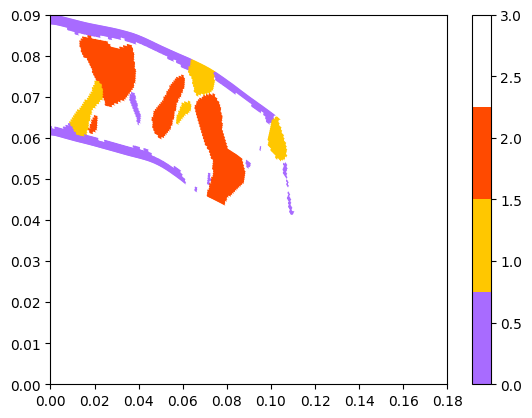

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.2087008645696207e-08
step 1/1
epoch 31 Loss 1.38E+00 J 8.50E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.288436286100464e-08
step 1/1
epoch 32 Loss 1.37E+00 J 8.54E+00 vf 0.00


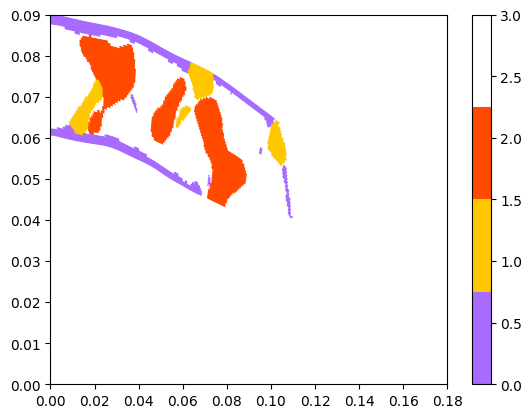

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.6694967400793455e-12
step 1/1
epoch 33 Loss 1.35E+00 J 8.28E+00 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 4.2874381088440355e-13
step 1/1
epoch 34 Loss 1.34E+00 J 8.17E+00 vf 0.00


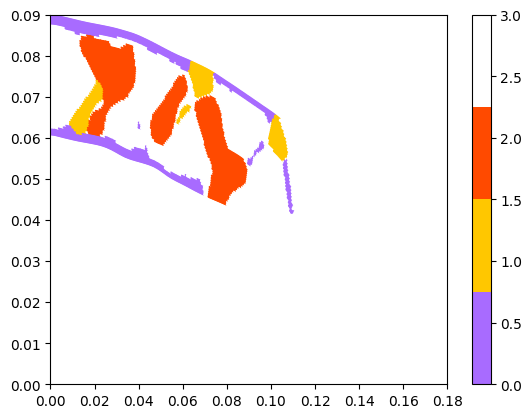

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 9.678767785680202e-08
step 1/1
epoch 35 Loss 1.32E+00 J 8.14E+00 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 9.037372422501657e-12
step 1/1
epoch 36 Loss 1.30E+00 J 8.19E+00 vf 0.00


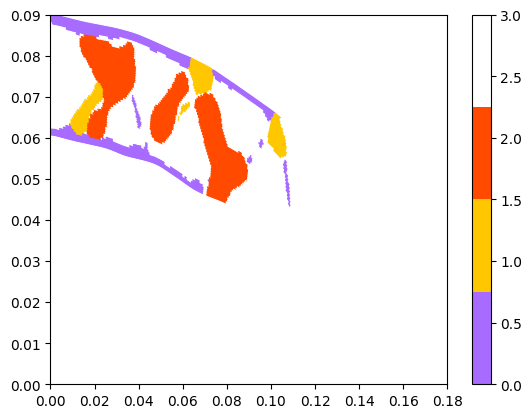

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.845493561738583e-10
step 1/1
epoch 37 Loss 1.28E+00 J 7.99E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.225302761990044e-08
step 1/1
epoch 38 Loss 1.26E+00 J 7.87E+00 vf 0.00


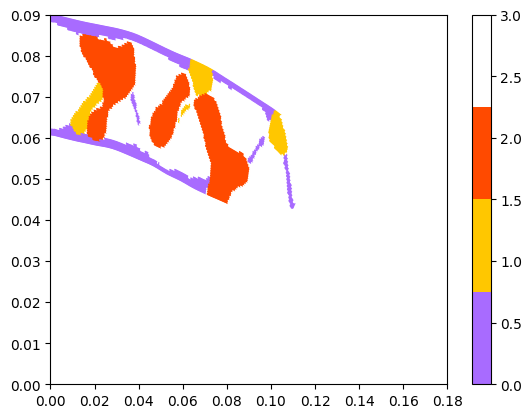

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.2980173780516519e-08
step 1/1
epoch 39 Loss 1.24E+00 J 7.75E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 5.0722780555322615e-08
step 1/1
epoch 40 Loss 1.22E+00 J 7.60E+00 vf 0.00


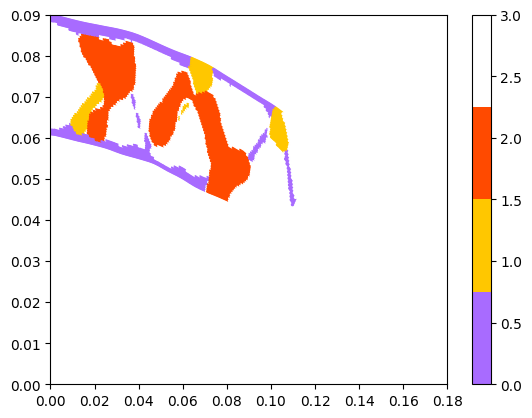

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.9802722755262824e-12
step 1/1
epoch 41 Loss 1.21E+00 J 7.68E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 7.05699269842747e-08
step 1/1
epoch 42 Loss 1.19E+00 J 7.60E+00 vf 0.00


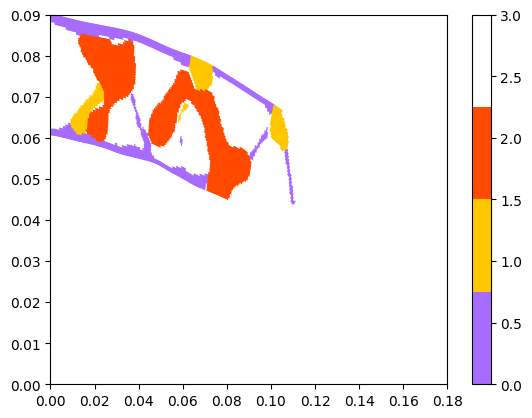

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.0986361014269643e-11
step 1/1
epoch 43 Loss 1.17E+00 J 7.40E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 9.544363020410611e-08
step 1/1
epoch 44 Loss 1.16E+00 J 7.27E+00 vf 0.00


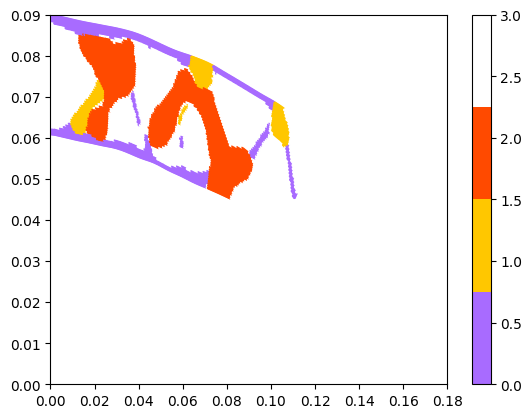

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 6.5710479541018e-08
step 1/1
epoch 45 Loss 1.14E+00 J 7.23E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 7.854637396336355e-08
step 1/1
epoch 46 Loss 1.13E+00 J 7.24E+00 vf 0.00


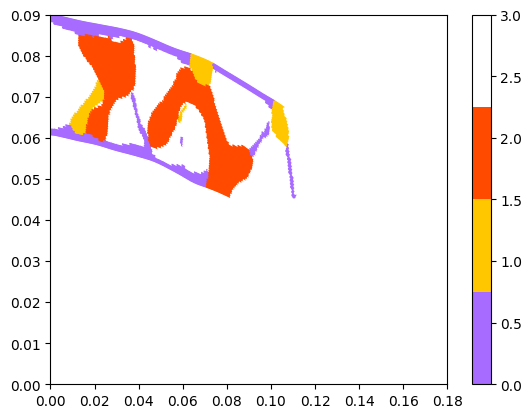

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.3715956455096414e-08
step 1/1
epoch 47 Loss 1.11E+00 J 7.19E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 7.50130780447035e-09
step 1/1
epoch 48 Loss 1.10E+00 J 7.09E+00 vf 0.00


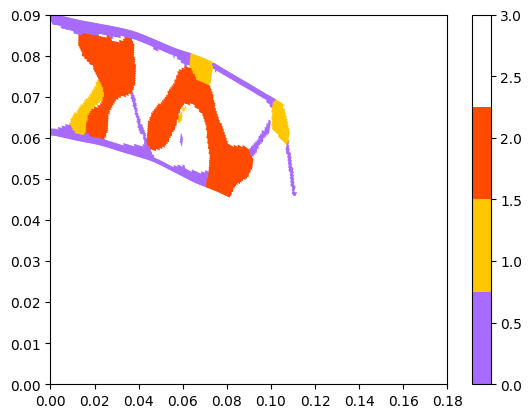

step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 9.220808332922248e-10
step 1/1
epoch 49 Loss 1.09E+00 J 7.04E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 6.776733756734614e-08
step 1/1
epoch 50 Loss 1.11E+00 J 6.91E+00 vf 0.00


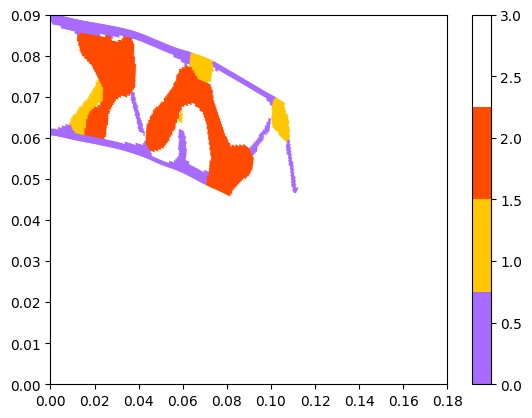

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.1749475576418787e-09
step 1/1
epoch 51 Loss 1.11E+00 J 7.09E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.165375367961736e-08
step 1/1
epoch 52 Loss 1.10E+00 J 7.17E+00 vf 0.00


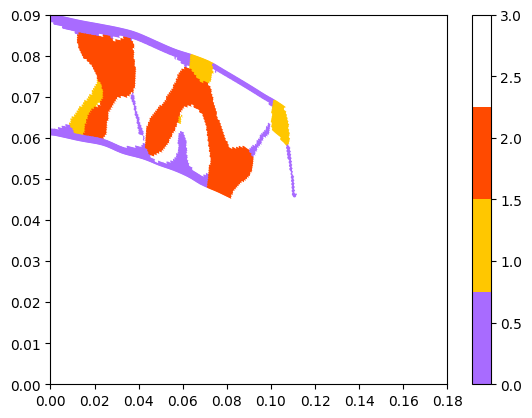

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.0937806931887067e-08
step 1/1
epoch 53 Loss 1.08E+00 J 6.90E+00 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.981810612723852e-10
step 1/1
epoch 54 Loss 1.06E+00 J 6.86E+00 vf 0.00


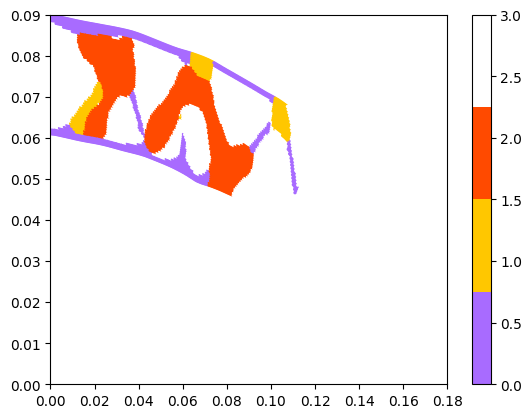

step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 1.8566658838928962e-11
step 1/1
epoch 55 Loss 1.05E+00 J 6.97E+00 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.9903400583173987e-08
step 1/1
epoch 56 Loss 1.03E+00 J 6.84E+00 vf 0.00


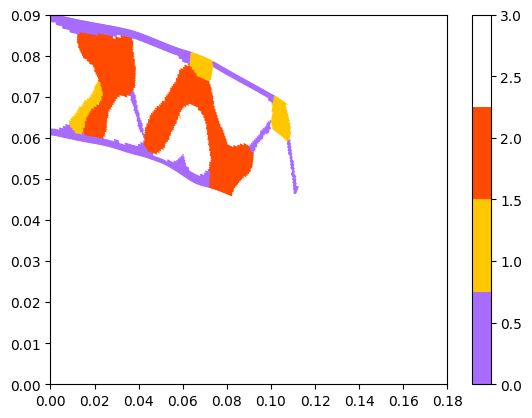

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.681370016500429e-13
step 1/1
epoch 57 Loss 1.01E+00 J 6.70E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.4043089194139014e-09
step 1/1
epoch 58 Loss 1.00E+00 J 6.63E+00 vf 0.00


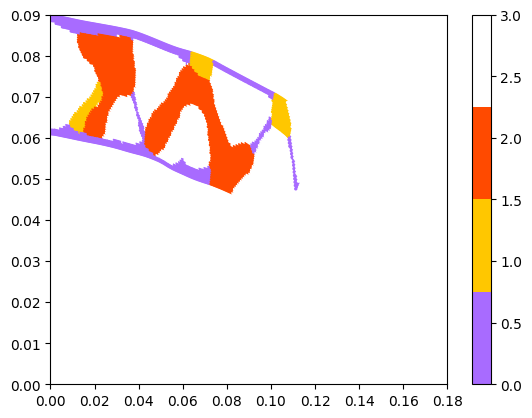

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.97583638933643e-08
step 1/1
epoch 59 Loss 9.92E-01 J 6.56E+00 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.3538354033803103e-12
step 1/1
epoch 60 Loss 9.82E-01 J 6.48E+00 vf 0.00


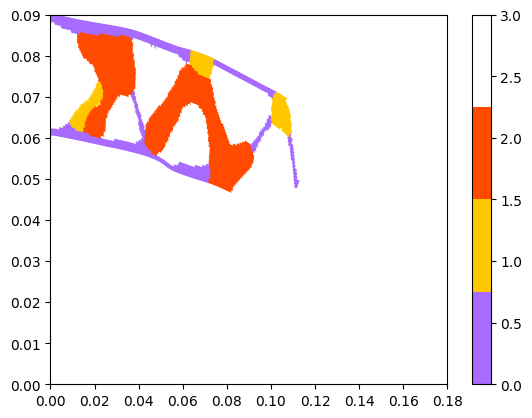

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.6450685308470393e-13
step 1/1
epoch 61 Loss 9.70E-01 J 6.43E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 5.327838061178105e-08
step 1/1
epoch 62 Loss 9.60E-01 J 6.44E+00 vf 0.00


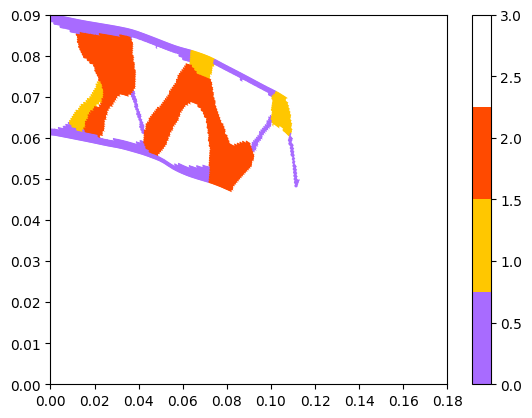

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.051519040333403e-08
step 1/1
epoch 63 Loss 9.53E-01 J 6.44E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 7.873020185974419e-08
step 1/1
epoch 64 Loss 9.44E-01 J 6.39E+00 vf 0.00


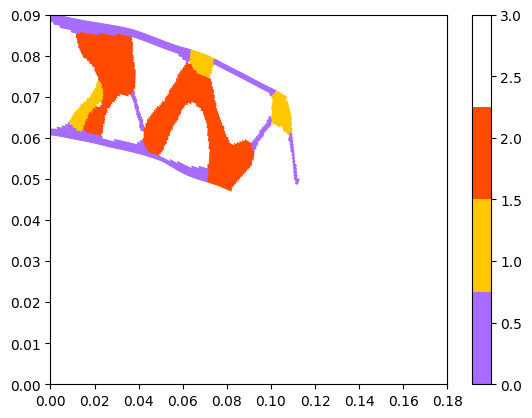

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.9594775184971043e-13
step 1/1
epoch 65 Loss 9.38E-01 J 6.36E+00 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.3415528081252683e-13
step 1/1
epoch 66 Loss 9.31E-01 J 6.33E+00 vf 0.00


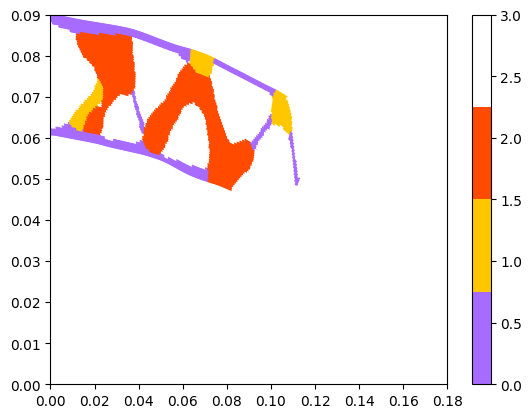

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.083112703222751e-08
step 1/1
epoch 67 Loss 9.22E-01 J 6.29E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 6.663473159187477e-09
step 1/1
epoch 68 Loss 9.14E-01 J 6.25E+00 vf 0.00


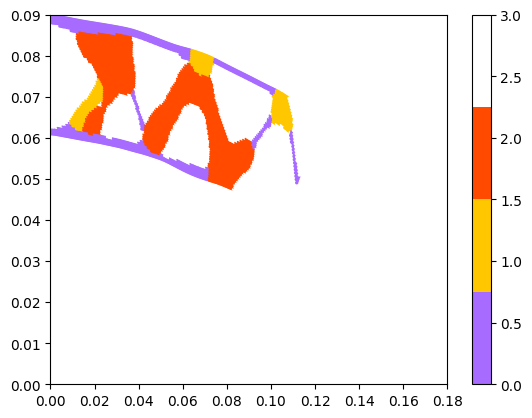

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.0576349916972643e-09
step 1/1
epoch 69 Loss 9.08E-01 J 6.21E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.3314130880113915e-09
step 1/1
epoch 70 Loss 9.02E-01 J 6.17E+00 vf 0.00


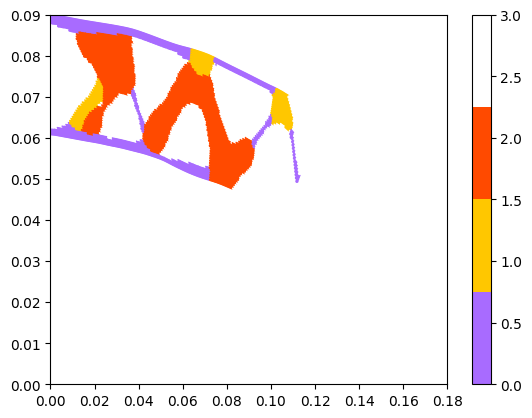

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 7.902972322401632e-09
step 1/1
epoch 71 Loss 8.96E-01 J 6.13E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.085570781937293e-08
step 1/1
epoch 72 Loss 8.90E-01 J 6.12E+00 vf 0.00


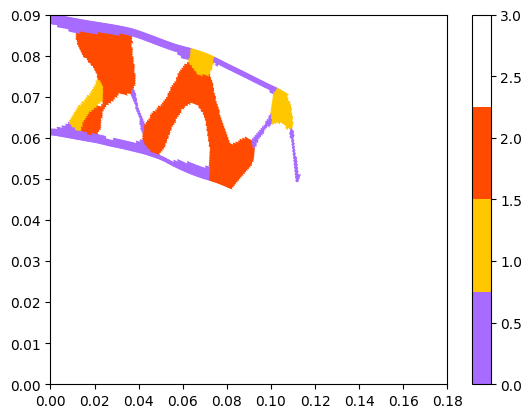

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.7500235255664455e-08
step 1/1
epoch 73 Loss 8.85E-01 J 6.12E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.4625381036182193e-08
step 1/1
epoch 74 Loss 8.79E-01 J 6.11E+00 vf 0.00


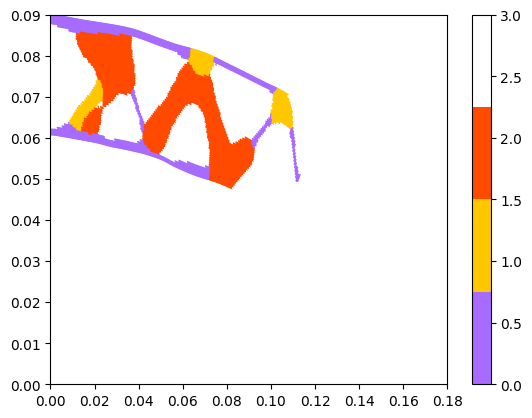

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.9406763691386104e-08
step 1/1
epoch 75 Loss 8.74E-01 J 6.10E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.278130526238598e-08
step 1/1
epoch 76 Loss 8.68E-01 J 6.08E+00 vf 0.00


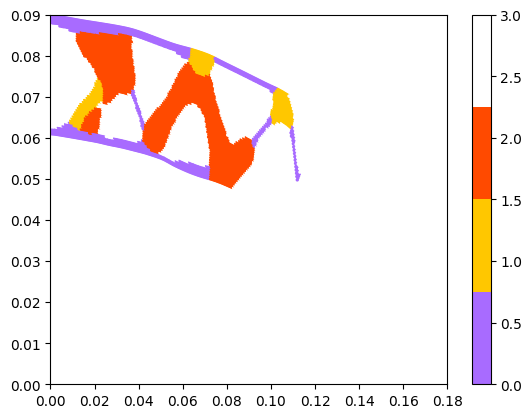

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 5.2422082511282683e-08
step 1/1
epoch 77 Loss 8.63E-01 J 6.07E+00 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 9.576543727222317e-13
step 1/1
epoch 78 Loss 8.58E-01 J 6.04E+00 vf 0.00


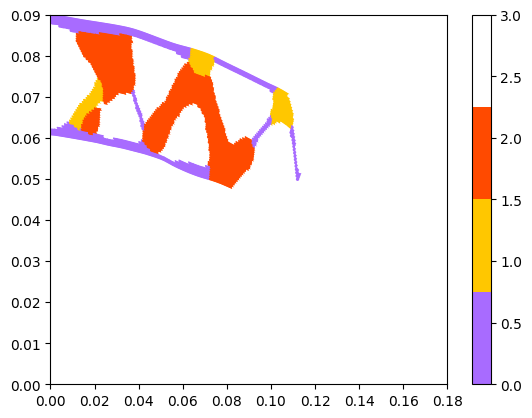

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.0601303804599133e-12
step 1/1
epoch 79 Loss 8.53E-01 J 6.03E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 9.226624337838175e-08
step 1/1
epoch 80 Loss 8.49E-01 J 6.01E+00 vf 0.00


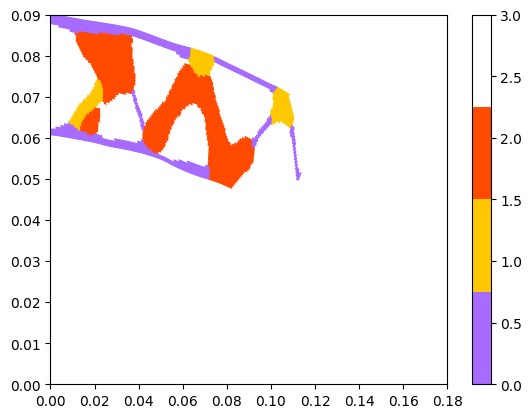

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.836259088685326e-08
step 1/1
epoch 81 Loss 8.44E-01 J 6.00E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.098545079102985e-08
step 1/1
epoch 82 Loss 8.39E-01 J 5.99E+00 vf 0.00


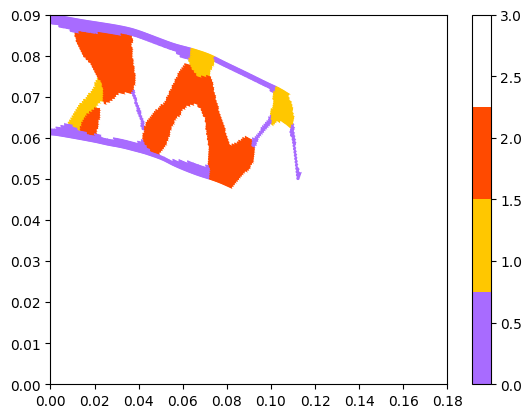

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.917804928696043e-08
step 1/1
epoch 83 Loss 8.34E-01 J 5.96E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 6.62882922688861e-08
step 1/1
epoch 84 Loss 8.29E-01 J 5.93E+00 vf 0.00


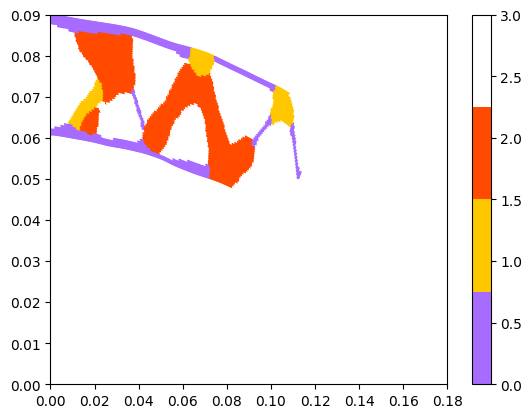

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 8.983917338555907e-08
step 1/1
epoch 85 Loss 8.25E-01 J 5.91E+00 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.997998487616826e-12
step 1/1
epoch 86 Loss 8.21E-01 J 5.90E+00 vf 0.00


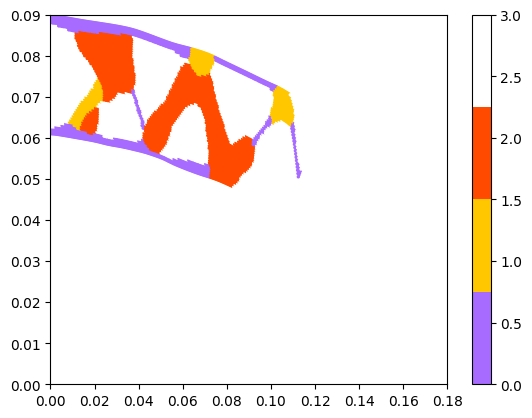

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 7.116634367037669e-08
step 1/1
epoch 87 Loss 8.17E-01 J 5.88E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 4.689964281050072e-08
step 1/1
epoch 88 Loss 8.12E-01 J 5.86E+00 vf 0.00


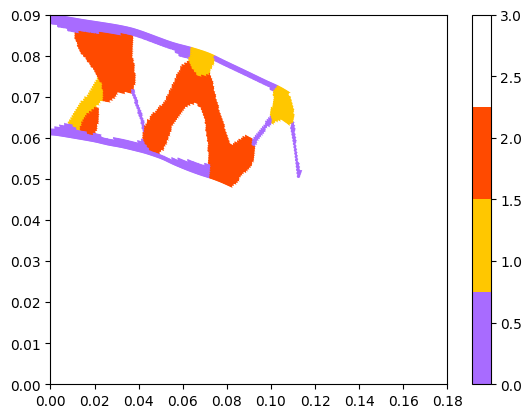

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.98101383952965e-08
step 1/1
epoch 89 Loss 8.08E-01 J 5.84E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.7243845603099197e-08
step 1/1
epoch 90 Loss 8.04E-01 J 5.82E+00 vf 0.00


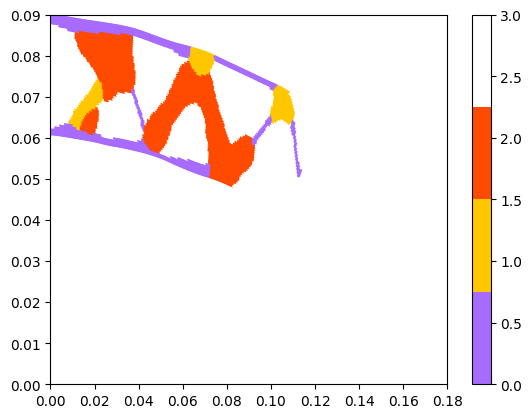

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 9.648603603987702e-09
step 1/1
epoch 91 Loss 8.00E-01 J 5.81E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 6.979355309667575e-09
step 1/1
epoch 92 Loss 7.96E-01 J 5.80E+00 vf 0.00


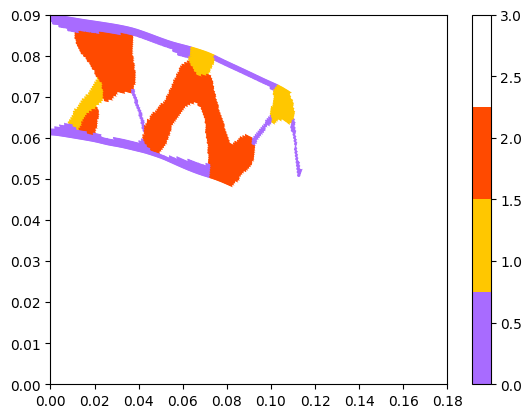

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 8.176950190001049e-09
step 1/1
epoch 93 Loss 7.93E-01 J 5.79E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.7558298106583406e-08
step 1/1
epoch 94 Loss 7.89E-01 J 5.77E+00 vf 0.00


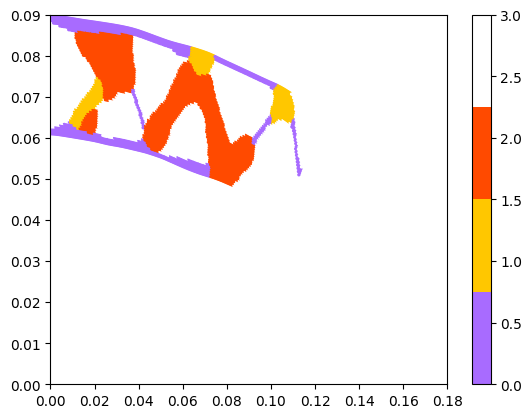

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 4.718902639594393e-08
step 1/1
epoch 95 Loss 7.85E-01 J 5.75E+00 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.890123573674536e-12
step 1/1
epoch 96 Loss 7.82E-01 J 5.74E+00 vf 0.00


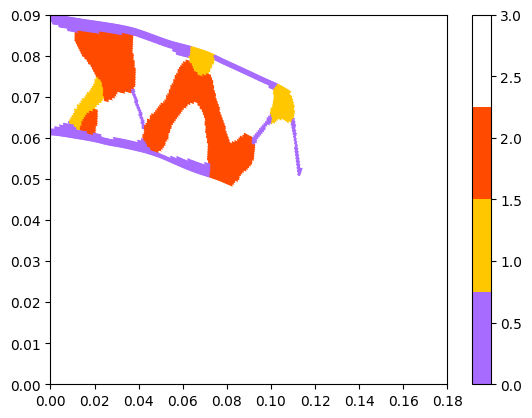

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.0482132477899909e-11
step 1/1
epoch 97 Loss 7.79E-01 J 5.72E+00 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 4.005940224278171e-11
step 1/1
epoch 98 Loss 7.75E-01 J 5.71E+00 vf 0.00


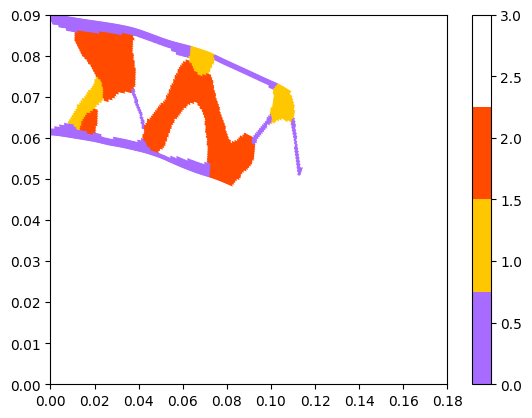

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 8.577200573570508e-11
step 1/1
epoch 99 Loss 7.72E-01 J 5.70E+00 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 8.036297689774984e-11
step 1/1
epoch 100 Loss 7.69E-01 J 5.69E+00 vf 0.00


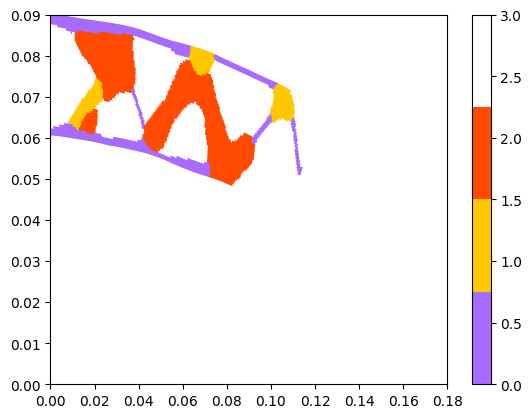

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.747492256339124e-11
step 1/1
epoch 101 Loss 7.66E-01 J 5.68E+00 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.1275923544491873e-11
step 1/1
epoch 102 Loss 7.63E-01 J 5.67E+00 vf 0.00


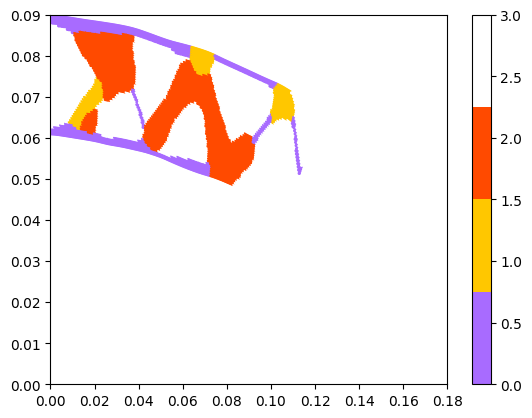

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.8297592051782583e-12
step 1/1
epoch 103 Loss 7.60E-01 J 5.67E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 5.3951673775593875e-08
step 1/1
epoch 104 Loss 7.57E-01 J 5.66E+00 vf 0.00


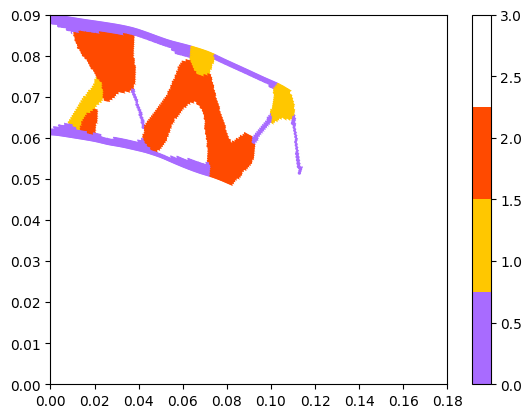

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.5418318654955443e-08
step 1/1
epoch 105 Loss 7.54E-01 J 5.65E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 7.456583986570243e-09
step 1/1
epoch 106 Loss 7.51E-01 J 5.64E+00 vf 0.00


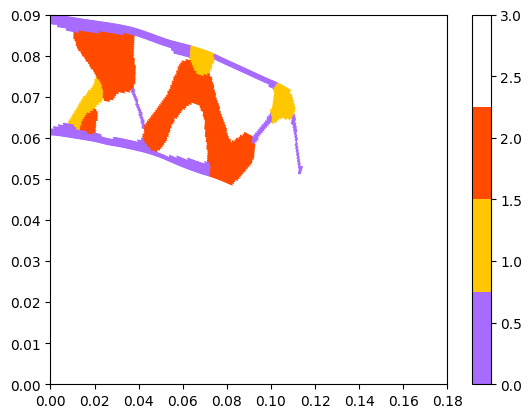

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 5.189071558095534e-09
step 1/1
epoch 107 Loss 7.48E-01 J 5.62E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 4.011144100378122e-09
step 1/1
epoch 108 Loss 7.46E-01 J 5.62E+00 vf 0.00


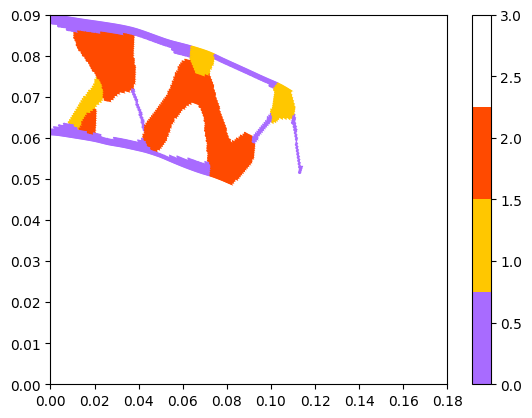

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 4.054477871062836e-09
step 1/1
epoch 109 Loss 7.43E-01 J 5.61E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 5.3216126660176886e-09
step 1/1
epoch 110 Loss 7.40E-01 J 5.59E+00 vf 0.00


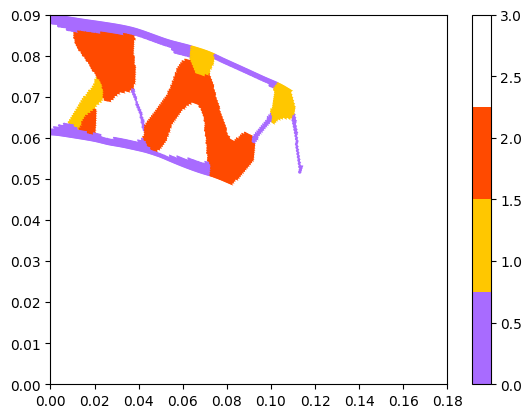

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 7.403714986885408e-09
step 1/1
epoch 111 Loss 7.38E-01 J 5.58E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 9.325329265507705e-09
step 1/1
epoch 112 Loss 7.35E-01 J 5.57E+00 vf 0.00


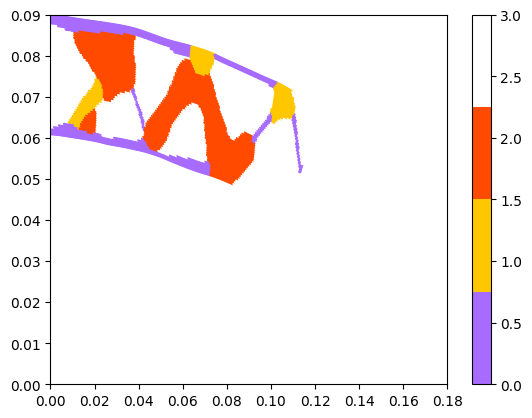

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.0368848487525967e-08
step 1/1
epoch 113 Loss 7.33E-01 J 5.56E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.0438015852903637e-08
step 1/1
epoch 114 Loss 7.30E-01 J 5.55E+00 vf 0.00


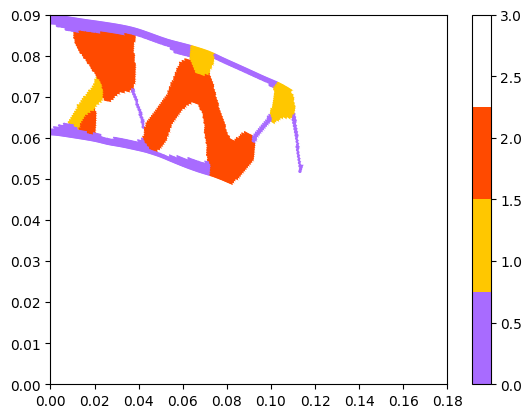

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 9.793621682135352e-09
step 1/1
epoch 115 Loss 7.28E-01 J 5.54E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 8.872383116903234e-09
step 1/1
epoch 116 Loss 7.25E-01 J 5.53E+00 vf 0.00


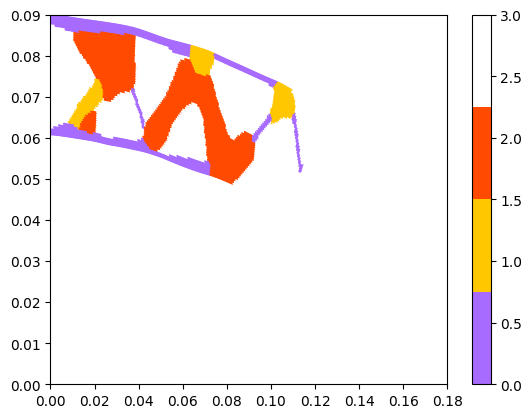

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 7.815103212311381e-09
step 1/1
epoch 117 Loss 7.23E-01 J 5.52E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 6.6025846901807495e-09
step 1/1
epoch 118 Loss 7.21E-01 J 5.51E+00 vf 0.00


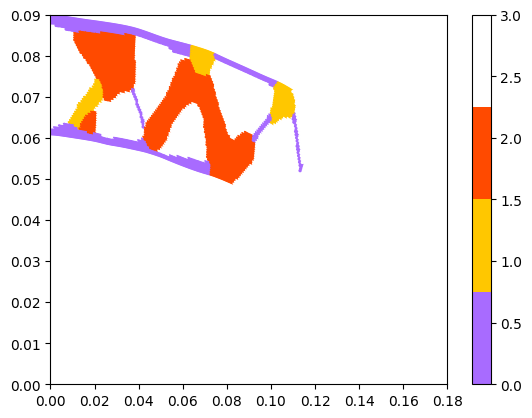

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 5.5140425264890646e-09
step 1/1
epoch 119 Loss 7.18E-01 J 5.50E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 4.715924951335234e-09
step 1/1
epoch 120 Loss 7.16E-01 J 5.49E+00 vf 0.00


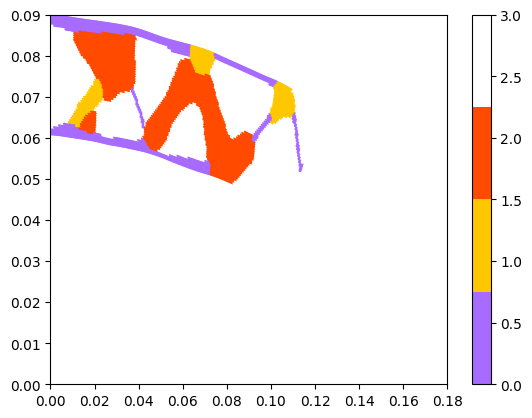

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 4.269589944193576e-09
step 1/1
epoch 121 Loss 7.14E-01 J 5.49E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 4.106188637806925e-09
step 1/1
epoch 122 Loss 7.12E-01 J 5.48E+00 vf 0.00


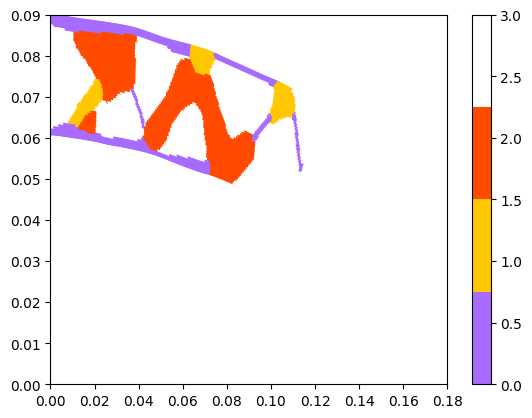

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 4.0462287394302725e-09
step 1/1
epoch 123 Loss 7.10E-01 J 5.47E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.967450456689501e-09
step 1/1
epoch 124 Loss 7.08E-01 J 5.47E+00 vf 0.00


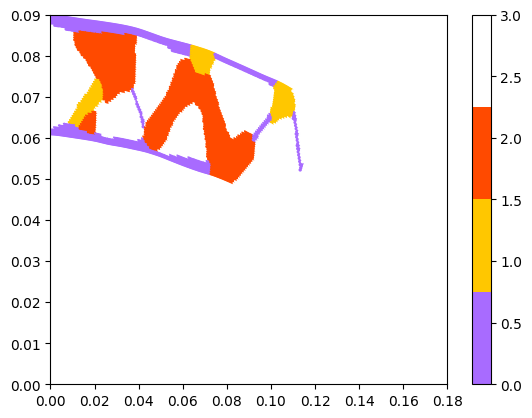

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.818925978865498e-09
step 1/1
epoch 125 Loss 7.06E-01 J 5.46E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.634212042196396e-09
step 1/1
epoch 126 Loss 7.04E-01 J 5.45E+00 vf 0.00


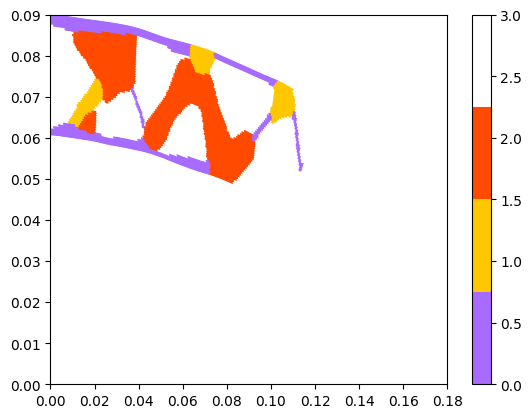

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.471873172908177e-09
step 1/1
epoch 127 Loss 7.02E-01 J 5.45E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.27022362236794e-09
step 1/1
epoch 128 Loss 7.00E-01 J 5.44E+00 vf 0.00


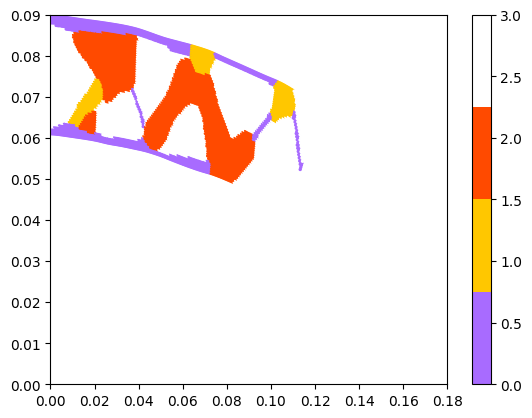

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.930015174448088e-09
step 1/1
epoch 129 Loss 6.98E-01 J 5.43E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 6.310420037982967e-09
step 1/1
epoch 130 Loss 6.96E-01 J 5.42E+00 vf 0.00


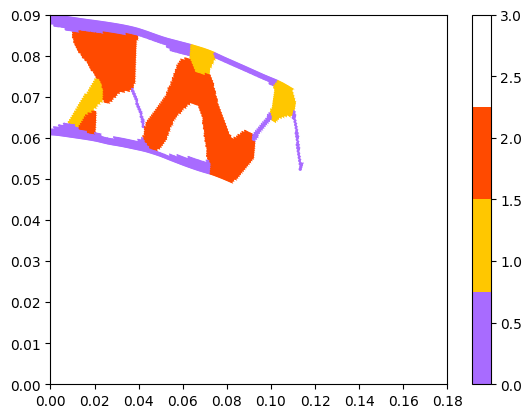

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 8.184294871967144e-09
step 1/1
epoch 131 Loss 6.94E-01 J 5.41E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 8.619882124374259e-09
step 1/1
epoch 132 Loss 6.92E-01 J 5.41E+00 vf 0.00


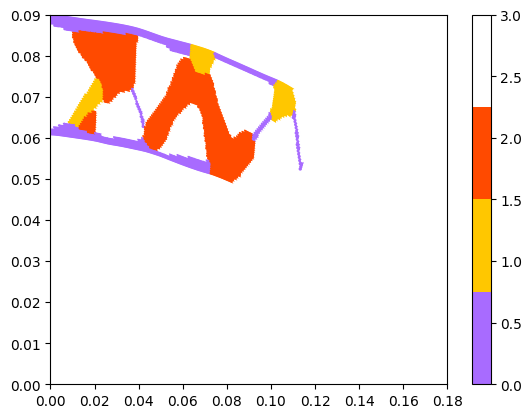

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 7.736632500159335e-09
step 1/1
epoch 133 Loss 6.91E-01 J 5.40E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 6.424114543068767e-09
step 1/1
epoch 134 Loss 6.89E-01 J 5.39E+00 vf 0.00


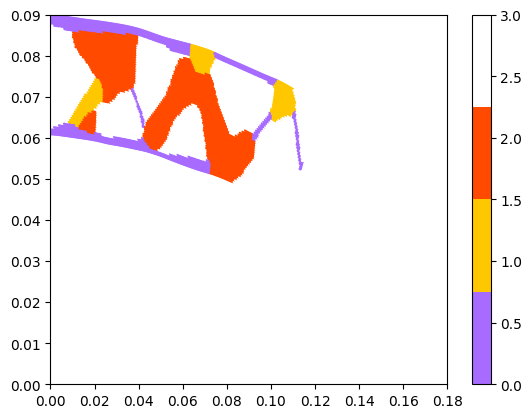

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 5.508737337189312e-09
step 1/1
epoch 135 Loss 6.87E-01 J 5.39E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 5.458102796015956e-09
step 1/1
epoch 136 Loss 6.85E-01 J 5.38E+00 vf 0.00


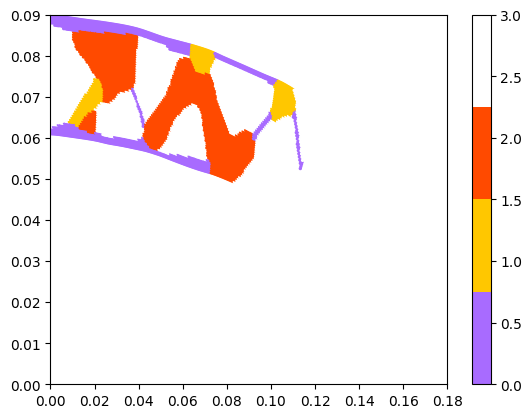

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 6.274205559454441e-09
step 1/1
epoch 137 Loss 6.84E-01 J 5.37E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 8.070668022119102e-09
step 1/1
epoch 138 Loss 6.82E-01 J 5.37E+00 vf 0.00


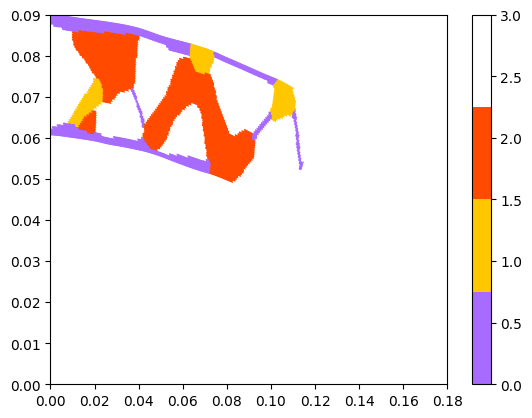

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.0532527841118737e-08
step 1/1
epoch 139 Loss 6.80E-01 J 5.36E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.3001366565237203e-08
step 1/1
epoch 140 Loss 6.79E-01 J 5.36E+00 vf 0.00


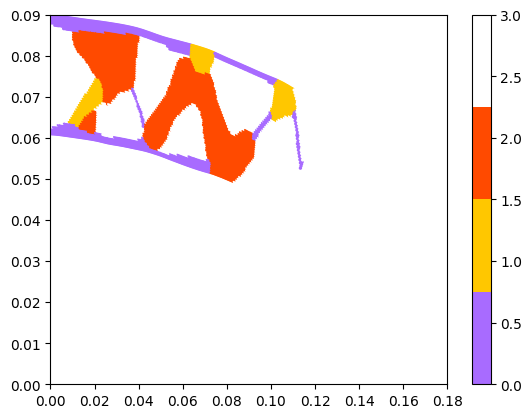

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.4617232555374184e-08
step 1/1
epoch 141 Loss 6.77E-01 J 5.35E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.611352727279007e-08
step 1/1
epoch 142 Loss 6.76E-01 J 5.34E+00 vf 0.00


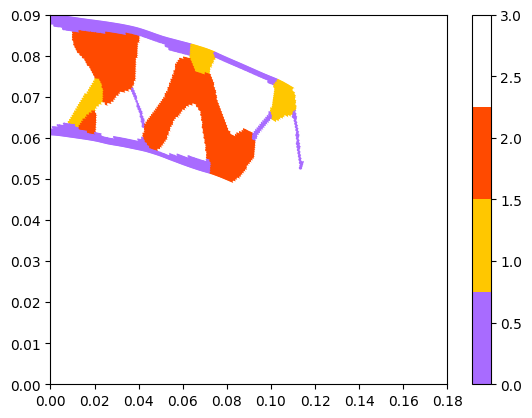

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.8351127290022643e-08
step 1/1
epoch 143 Loss 6.74E-01 J 5.33E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.1474649465408757e-08
step 1/1
epoch 144 Loss 6.72E-01 J 5.32E+00 vf 0.00


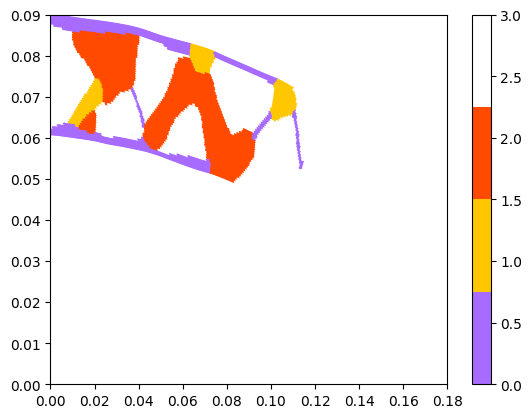

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.361806710306931e-08
step 1/1
epoch 145 Loss 6.71E-01 J 5.32E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.3450989591867467e-08
step 1/1
epoch 146 Loss 6.69E-01 J 5.31E+00 vf 0.00


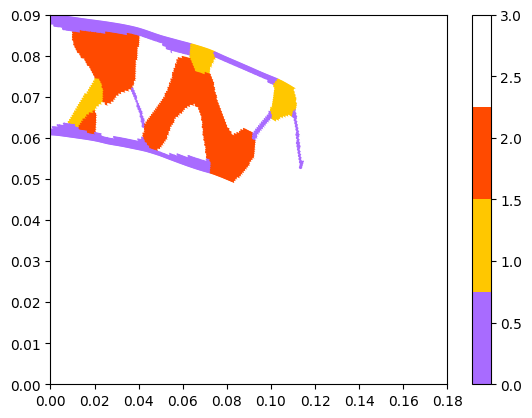

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.206133357243967e-08
step 1/1
epoch 147 Loss 6.68E-01 J 5.30E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.1406940399149644e-08
step 1/1
epoch 148 Loss 6.66E-01 J 5.30E+00 vf 0.00


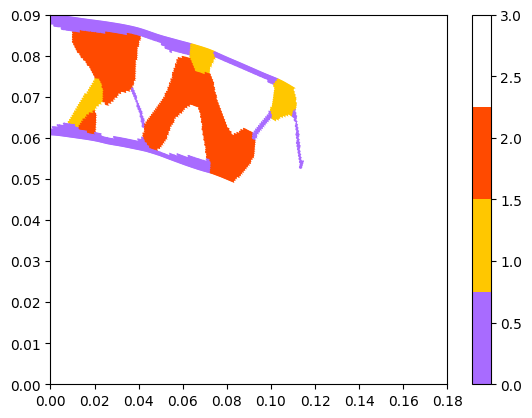

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.1377438210005412e-08
step 1/1
epoch 149 Loss 6.65E-01 J 5.29E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.0910242743280475e-08
step 1/1
epoch 150 Loss 6.63E-01 J 5.29E+00 vf 0.00


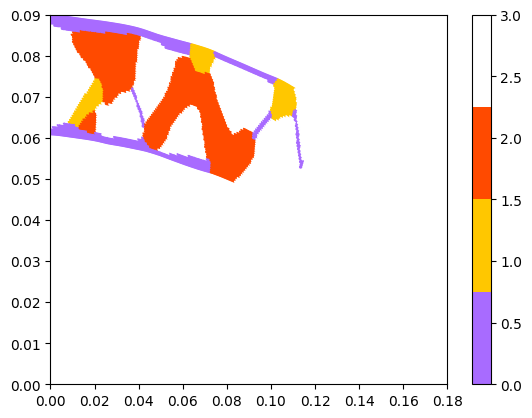

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.997586999780562e-08
step 1/1
epoch 151 Loss 6.62E-01 J 5.28E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.9969623065190837e-08
step 1/1
epoch 152 Loss 6.61E-01 J 5.28E+00 vf 0.00


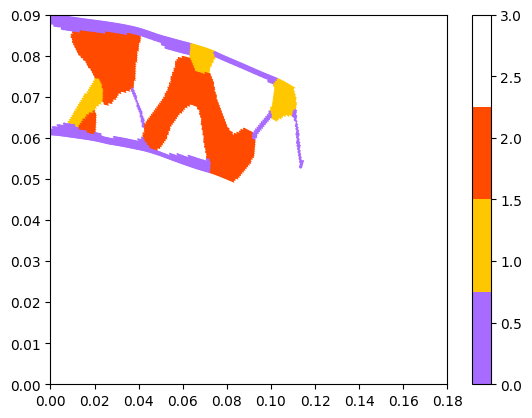

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.129075942323813e-08
step 1/1
epoch 153 Loss 6.59E-01 J 5.27E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.402213623521515e-08
step 1/1
epoch 154 Loss 6.58E-01 J 5.27E+00 vf 0.00


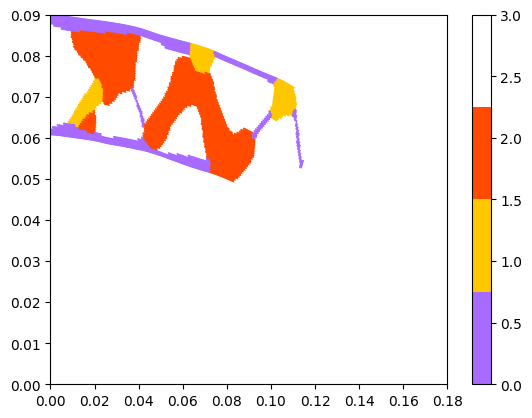

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.746806207699963e-08
step 1/1
epoch 155 Loss 6.57E-01 J 5.26E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.025103732809851e-08
step 1/1
epoch 156 Loss 6.55E-01 J 5.26E+00 vf 0.00


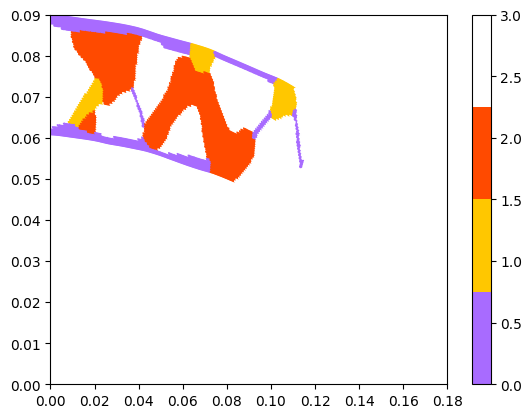

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.160145374125049e-08
step 1/1
epoch 157 Loss 6.54E-01 J 5.25E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.170958003312722e-08
step 1/1
epoch 158 Loss 6.53E-01 J 5.25E+00 vf 0.00


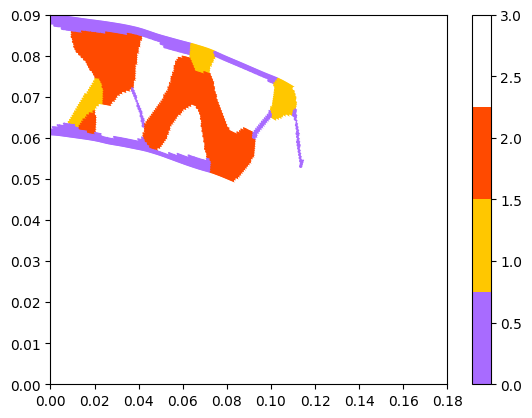

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.134755045103568e-08
step 1/1
epoch 159 Loss 6.51E-01 J 5.24E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.9720637925993857e-08
step 1/1
epoch 160 Loss 6.50E-01 J 5.23E+00 vf 0.00


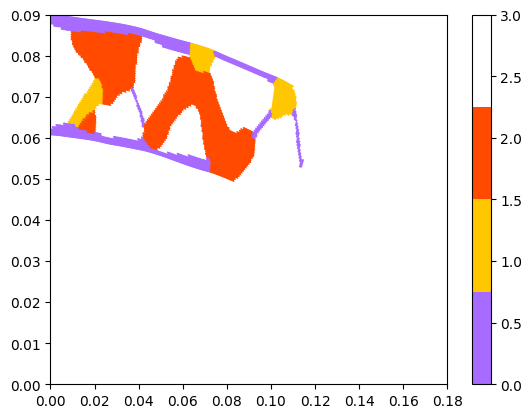

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.6937603286841357e-08
step 1/1
epoch 161 Loss 6.48E-01 J 5.22E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.4700808425567937e-08
step 1/1
epoch 162 Loss 6.47E-01 J 5.21E+00 vf 0.00


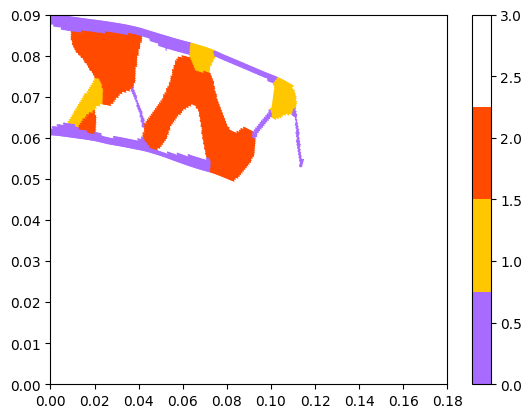

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.4067123850982122e-08
step 1/1
epoch 163 Loss 6.45E-01 J 5.19E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.4642261526639314e-08
step 1/1
epoch 164 Loss 6.44E-01 J 5.19E+00 vf 0.00


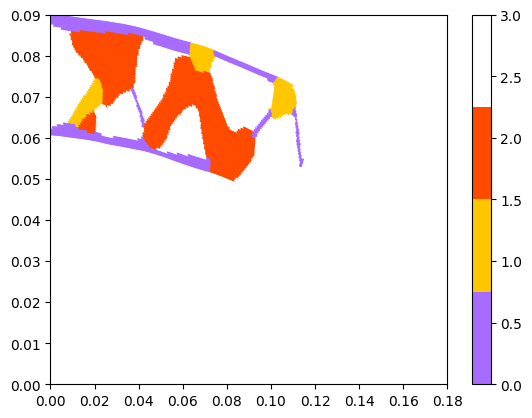

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.3907660477911535e-08
step 1/1
epoch 165 Loss 6.42E-01 J 5.18E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.1701393939594894e-08
step 1/1
epoch 166 Loss 6.41E-01 J 5.17E+00 vf 0.00


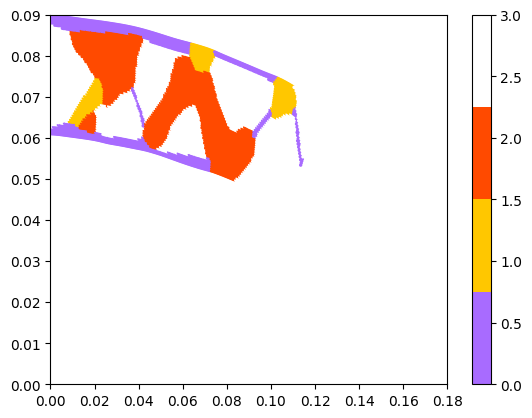

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.0766611961077263e-08
step 1/1
epoch 167 Loss 6.40E-01 J 5.17E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.1057632317418415e-08
step 1/1
epoch 168 Loss 6.39E-01 J 5.16E+00 vf 0.00


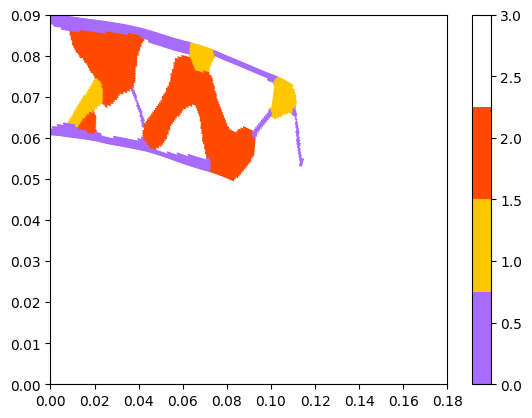

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.1979223980672088e-08
step 1/1
epoch 169 Loss 6.38E-01 J 5.16E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.2978455517073078e-08
step 1/1
epoch 170 Loss 6.37E-01 J 5.16E+00 vf 0.00


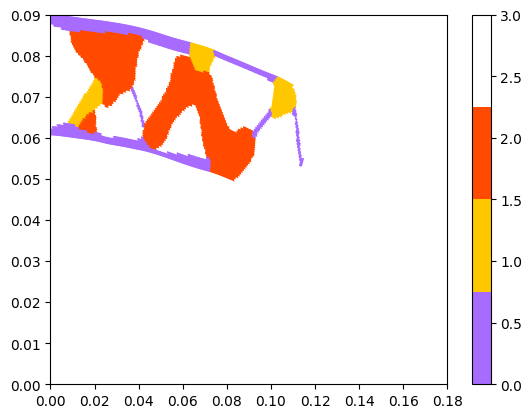

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.4016636907808804e-08
step 1/1
epoch 171 Loss 6.36E-01 J 5.16E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.5820688566664525e-08
step 1/1
epoch 172 Loss 6.35E-01 J 5.15E+00 vf 0.00


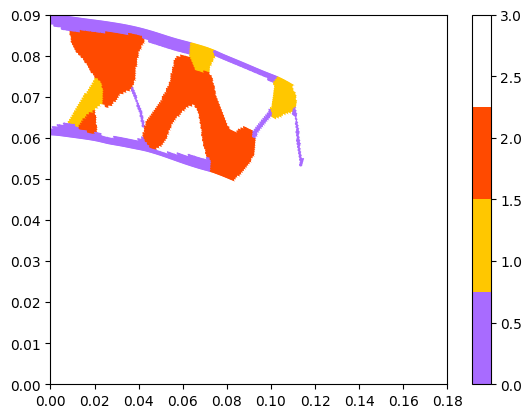

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.9489430512043594e-08
step 1/1
epoch 173 Loss 6.34E-01 J 5.15E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.448595288456257e-08
step 1/1
epoch 174 Loss 6.33E-01 J 5.15E+00 vf 0.00


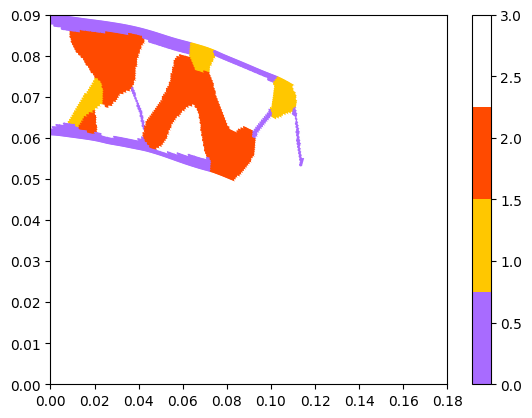

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.832200002632173e-08
step 1/1
epoch 175 Loss 6.32E-01 J 5.15E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.837412298725949e-08
step 1/1
epoch 176 Loss 6.31E-01 J 5.14E+00 vf 0.00


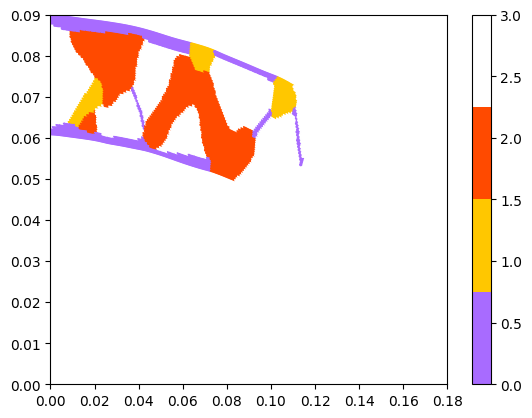

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.631983803119555e-08
step 1/1
epoch 177 Loss 6.30E-01 J 5.14E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.518172605733337e-08
step 1/1
epoch 178 Loss 6.29E-01 J 5.14E+00 vf 0.00


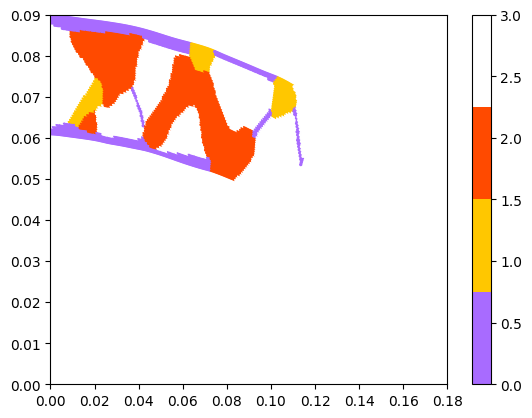

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.718371774555852e-08
step 1/1
epoch 179 Loss 6.28E-01 J 5.13E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 4.2733656736313664e-08
step 1/1
epoch 180 Loss 6.27E-01 J 5.13E+00 vf 0.00


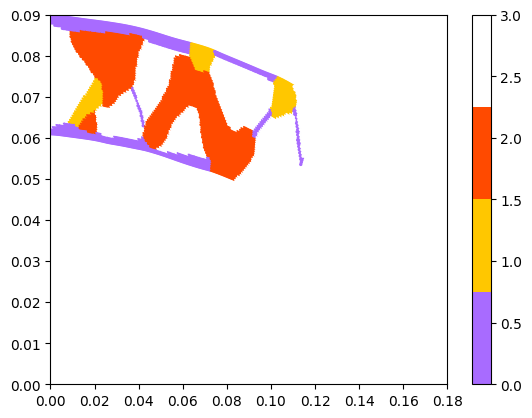

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 4.783520024461753e-08
step 1/1
epoch 181 Loss 6.26E-01 J 5.13E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 5.218939142737943e-08
step 1/1
epoch 182 Loss 6.25E-01 J 5.12E+00 vf 0.00


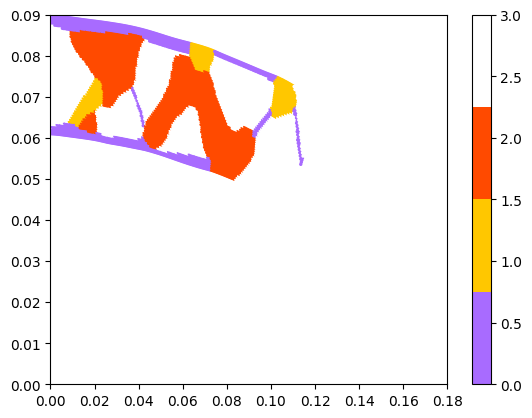

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 5.6660806324522434e-08
step 1/1
epoch 183 Loss 6.24E-01 J 5.12E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 6.481688974802068e-08
step 1/1
epoch 184 Loss 6.24E-01 J 5.12E+00 vf 0.00


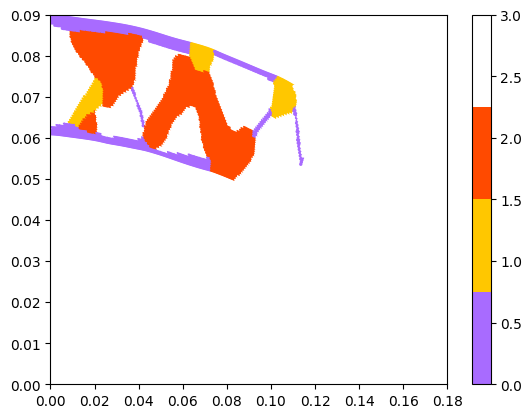

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 7.139326958106598e-08
step 1/1
epoch 185 Loss 6.23E-01 J 5.12E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 7.054266538008076e-08
step 1/1
epoch 186 Loss 6.22E-01 J 5.11E+00 vf 0.00


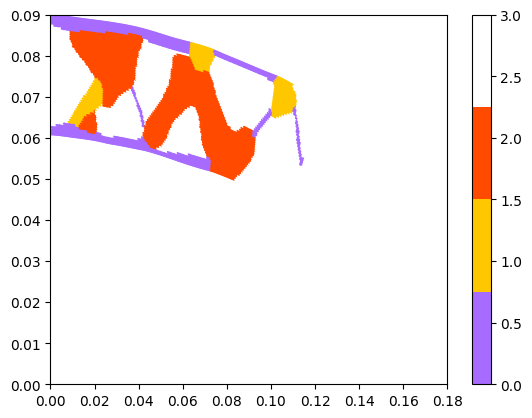

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 6.445719888440463e-08
step 1/1
epoch 187 Loss 6.21E-01 J 5.11E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 6.046065919660247e-08
step 1/1
epoch 188 Loss 6.20E-01 J 5.11E+00 vf 0.00


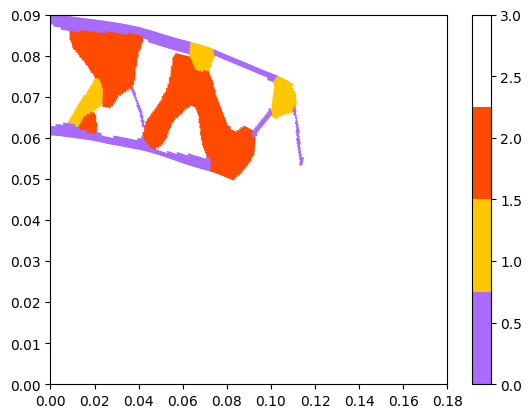

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 6.420925984402192e-08
step 1/1
epoch 189 Loss 6.20E-01 J 5.11E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 7.35797924774589e-08
step 1/1
epoch 190 Loss 6.19E-01 J 5.10E+00 vf 0.00


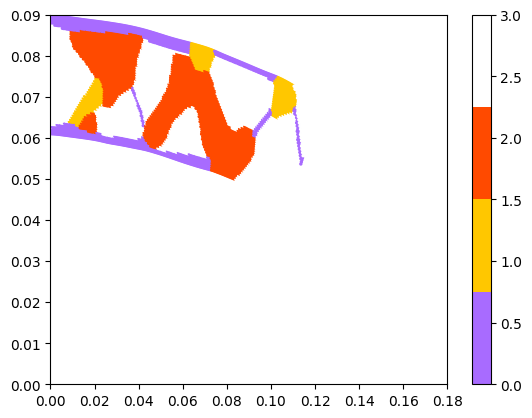

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 8.233811426483999e-08
step 1/1
epoch 191 Loss 6.18E-01 J 5.10E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 8.498642058666626e-08
step 1/1
epoch 192 Loss 6.17E-01 J 5.10E+00 vf 0.00


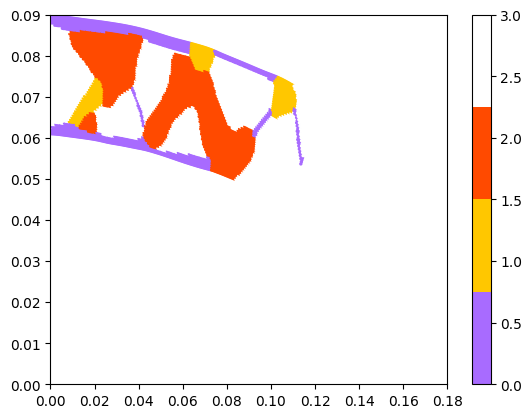

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 8.996933347058381e-08
step 1/1
epoch 193 Loss 6.17E-01 J 5.10E+00 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 9.838273010334984e-08
step 1/1
epoch 194 Loss 6.16E-01 J 5.09E+00 vf 0.00


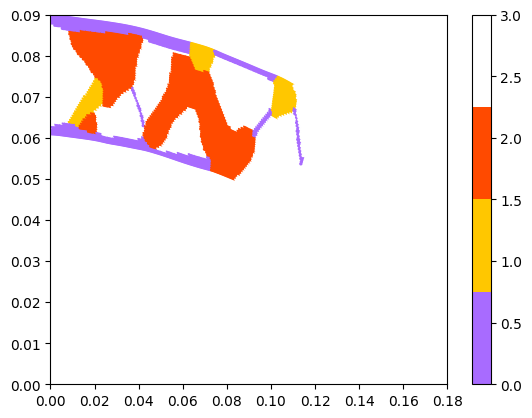

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 4.128577988119874e-13
step 1/1
epoch 195 Loss 6.15E-01 J 5.09E+00 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 4.263161149957545e-13
step 1/1
epoch 196 Loss 6.14E-01 J 5.09E+00 vf 0.00


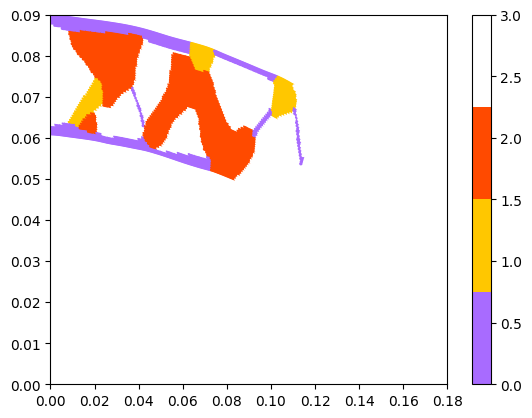

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 4.6365720248085e-13
step 1/1
epoch 197 Loss 6.14E-01 J 5.08E+00 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 4.221339016235588e-13
step 1/1
epoch 198 Loss 6.13E-01 J 5.08E+00 vf 0.00


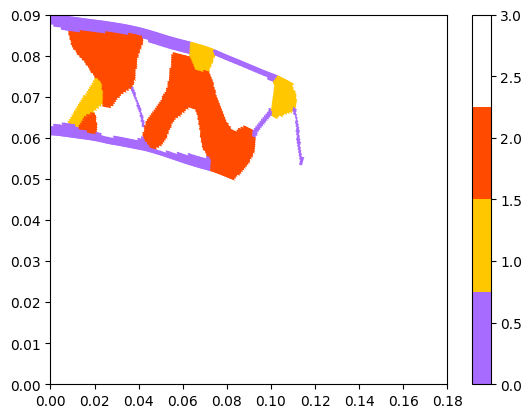

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.718275401133526e-13
step 1/1
epoch 199 Loss 6.12E-01 J 5.08E+00 vf 0.00


In [20]:
mp_final, mat_fracs, net, convg_history = optimize_design(
  net=topnet,
  mp_state0=mp_state,
  max_mass=max_mass,
  max_epoch=200,
  lr=1e-2,
  num_load_steps=1,
  gravity_vec=gravity_vec,
)

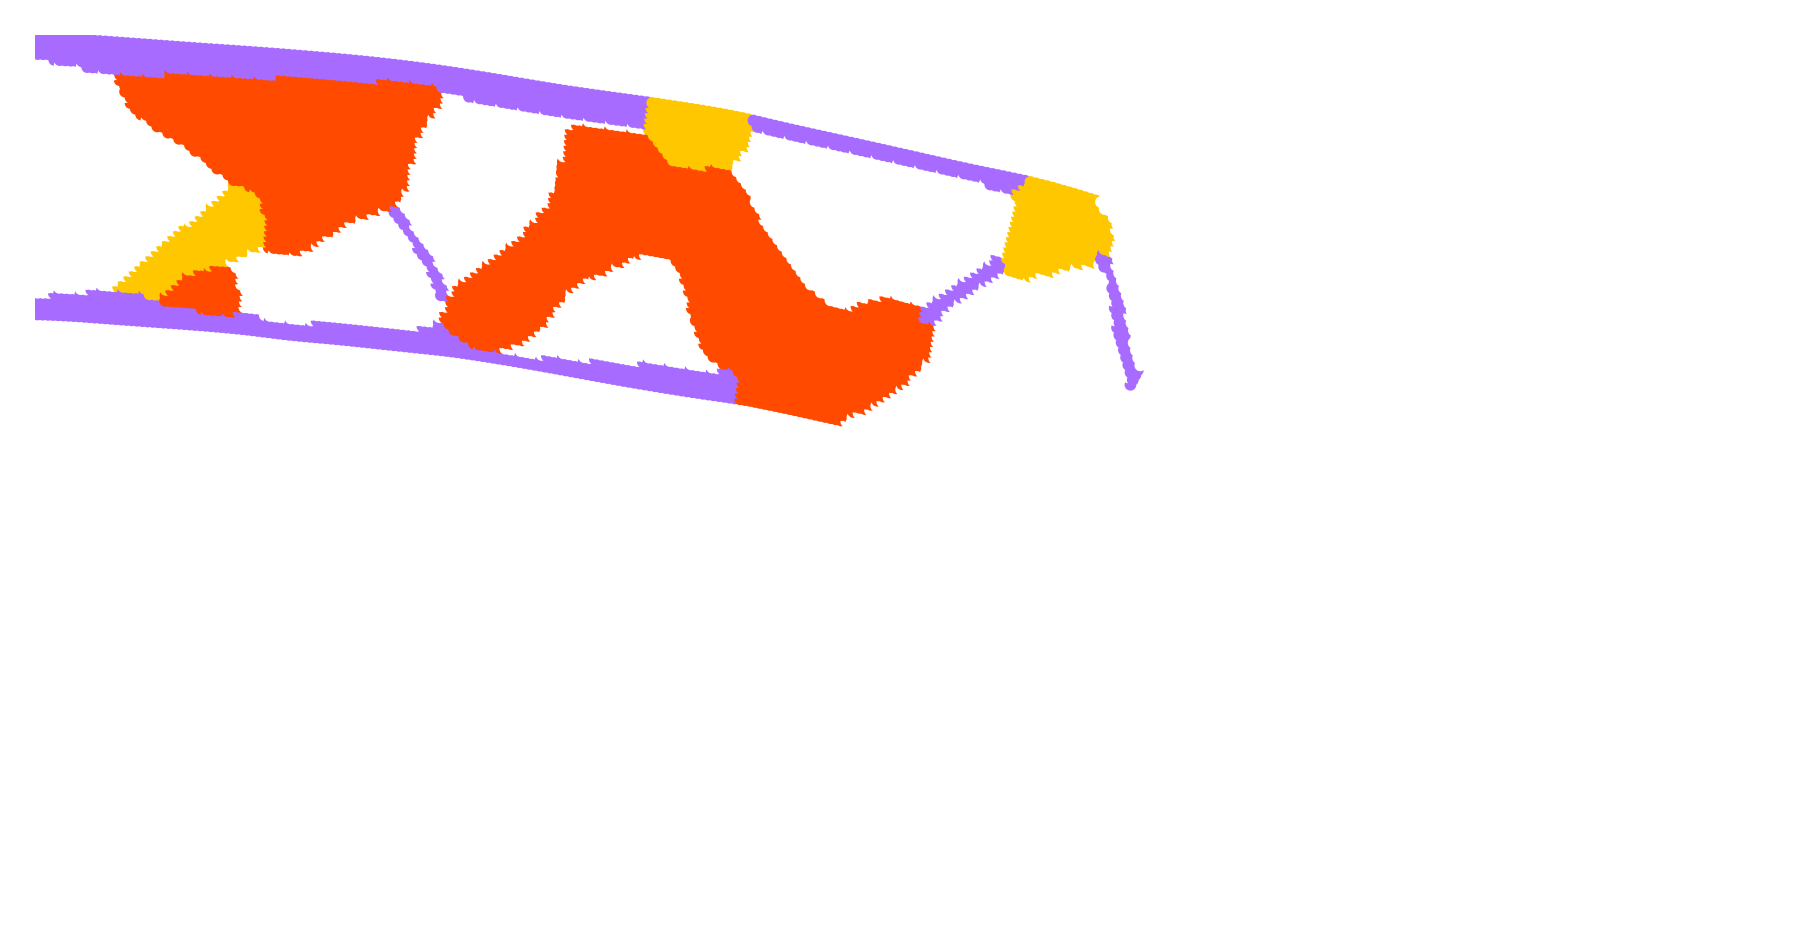

In [21]:
cmap = mplib.colors.ListedColormap(_viz.mat_colors[:num_materials])
plt.rcParams.update(_viz.high_res_plot_settings)
coords = np.asarray(mp_final.coord)
mat_idx = jnp.argmax(mat_fracs, axis=-1)

_, ax = plt.subplots()
img = ax.scatter(coords[:, 0], coords[:, 1], s=2, c=mat_idx, cmap=cmap)
ax.set_xlim([float(mesh.bounding_box.x.min), float(mesh.bounding_box.x.max)])
ax.set_ylim([float(mesh.bounding_box.y.min), float(mesh.bounding_box.y.max)])
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")

plt.savefig("result_mmto.svg", format="svg", bbox_inches="tight")
plt.show()
